In [25]:
import importlib

import notebook_ui

importlib.reload(notebook_ui)

from notebook_ui import show_block

show_block(
    "notebook_ui/classic_html/00_classic_header.html",
    "notebook_ui/styles/header.css",
)

In [2]:
show_block(
    "notebook_ui/classic_html/00_classic_navigation.html",
    "notebook_ui/styles/navigation.css",
)

In [3]:
show_block(
    "notebook_ui/classic_html/01_classic_loadlibpath.html",
    "notebook_ui/styles/middle.css",
)

In [4]:
import json
import random
import sys
import time
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 10

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

CLEAN_DATA_PATH = Path("../data/processed/sentipers_clean_v1.csv")

CLASSIC_TABLES_DIR = Path("../outputs/tables/03_classic_models")

CLASSIC_FIGURES_DIR = Path("../outputs/figures/03_classic_models")

CLASSIC_MODELS_DIR = Path("../outputs/models/03_classic_models")

CLASSIC_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CLASSIC_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CLASSIC_MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not CLEAN_DATA_PATH.is_file():
    raise FileNotFoundError(f"Clean dataset not found: " f"{CLEAN_DATA_PATH.resolve()}")

environment_summary = pd.DataFrame(
    {
        "item": [
            "python_version",
            "pandas_version",
            "numpy_version",
            "scikit_learn_version",
            "matplotlib_version",
            "random_state",
            "test_size",
            "cv_folds",
        ],
        "value": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            sklearn.__version__,
            matplotlib.__version__,
            RANDOM_STATE,
            TEST_SIZE,
            CV_FOLDS,
        ],
    }
)

print(f"Clean dataset: " f"{CLEAN_DATA_PATH.resolve()}")

print(f"Tables directory: " f"{CLASSIC_TABLES_DIR.resolve()}")

print(f"Figures directory: " f"{CLASSIC_FIGURES_DIR.resolve()}")

print(f"Models directory: " f"{CLASSIC_MODELS_DIR.resolve()}")

print("Classic modeling environment is ready.")

display(environment_summary)

Clean dataset: D:\Bachelor Project\PersianSentimentProject\data\processed\sentipers_clean_v1.csv
Tables directory: D:\Bachelor Project\PersianSentimentProject\outputs\tables\03_classic_models
Figures directory: D:\Bachelor Project\PersianSentimentProject\outputs\figures\03_classic_models
Models directory: D:\Bachelor Project\PersianSentimentProject\outputs\models\03_classic_models
Classic modeling environment is ready.


,item,value
0,python_version,3.10.0
1,pandas_version,2.3.3
2,numpy_version,2.2.6
3,scikit_learn_version,1.7.2
4,matplotlib_version,3.10.7
5,random_state,42
6,test_size,0.2
7,cv_folds,10


In [4]:
show_block(
    "notebook_ui/classic_html/02_classic_load_clean_data.html",
    "notebook_ui/styles/middle.css"
)

In [6]:
TEXT_COLUMN = "text"
TARGET_COLUMN = "polarity"

REQUIRED_COLUMNS = [
    TEXT_COLUMN,
    TARGET_COLUMN,
]

modeling_df = pd.read_csv(
    CLEAN_DATA_PATH,
    encoding="utf-8-sig",
)

missing_columns = [
    column for column in REQUIRED_COLUMNS if column not in modeling_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: " f"{missing_columns}")

if modeling_df.empty:
    raise ValueError("The modeling dataset is empty.")

DATASET_ROW_COUNT = len(modeling_df)

DATASET_COLUMN_COUNT = modeling_df.shape[1]

DATASET_MEMORY_MB = modeling_df.memory_usage(deep=True).sum() / (1024**2)

MISSING_TEXT_COUNT = modeling_df[TEXT_COLUMN].isna().sum()

MISSING_TARGET_COUNT = modeling_df[TARGET_COLUMN].isna().sum()

dataset_load_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "memory_mb",
            "missing_text_values",
            "missing_target_values",
        ],
        "value": [
            DATASET_ROW_COUNT,
            DATASET_COLUMN_COUNT,
            round(
                DATASET_MEMORY_MB,
                3,
            ),
            MISSING_TEXT_COUNT,
            MISSING_TARGET_COUNT,
        ],
    }
)

assert DATASET_ROW_COUNT > 0

assert all(column in modeling_df.columns for column in REQUIRED_COLUMNS)

print(f"Dataset rows: " f"{DATASET_ROW_COUNT:,}")

print(f"Dataset columns: " f"{DATASET_COLUMN_COUNT:,}")

print(f"Dataset memory: " f"{DATASET_MEMORY_MB:.3f} MB")

print(f"Missing text values: " f"{MISSING_TEXT_COUNT:,}")

print(f"Missing target values: " f"{MISSING_TARGET_COUNT:,}")

print("Clean dataset loaded successfully.")

display(dataset_load_summary)

display(modeling_df.head())

Dataset rows: 13,094
Dataset columns: 5
Dataset memory: 5.749 MB
Missing text values: 0
Missing target values: 0
Clean dataset loaded successfully.


,metric,value
0,rows,13094.000
1,columns,5.000
2,memory_mb,5.749
3,missing_text_values,0.000
4,missing_target_values,0.000


,index,sid,text,polarity,file
0,0,rev-1,اینک قصد داریم پرینتر دیگری از پرینترهای لیزری...,0,data/main/HP LaserJet M1132.xml
1,1,rev-2,پرینتری چند کاره از رده‌ی Entry Level یا سطح م...,0,data/main/HP LaserJet M1132.xml
2,2,rev-3,به هر صورت اکنون ما در دنیایی زندگی می‌کنیم، ک...,0,data/main/HP LaserJet M1132.xml
3,3,rev-4,به صورتی که توانایی کپی کردن، اسکن، فکس، پرینت...,0,data/main/HP LaserJet M1132.xml
4,4,rev-5,به هر صورت معمولا چیزی که بیشتر کاربران از پری...,2,data/main/HP LaserJet M1132.xml


In [5]:
show_block(
    "notebook_ui/classic_html/03_classic_data_overview.html",
    "notebook_ui/styles/middle.css"
)

In [8]:
EXPECTED_CLASS_COUNT = 5

CLASS_COUNT = modeling_df[TARGET_COLUMN].nunique()

BLANK_TEXT_COUNT = modeling_df[TEXT_COLUMN].fillna("").str.strip().eq("").sum()

DUPLICATE_TEXT_COUNT = modeling_df[TEXT_COLUMN].duplicated().sum()

class_distribution = (
    modeling_df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"].div(DATASET_ROW_COUNT).mul(100).round(2)
)

MINIMUM_CLASS_SIZE = class_distribution["count"].min()

MAXIMUM_CLASS_SIZE = class_distribution["count"].max()

CLASS_IMBALANCE_RATIO = round(
    MAXIMUM_CLASS_SIZE / MINIMUM_CLASS_SIZE,
    3,
)

modeling_data_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "class_count",
            "blank_text_rows",
            "missing_target_rows",
            "duplicate_text_rows",
            "minimum_class_size",
            "maximum_class_size",
            "class_imbalance_ratio",
        ],
        "value": [
            DATASET_ROW_COUNT,
            CLASS_COUNT,
            BLANK_TEXT_COUNT,
            MISSING_TARGET_COUNT,
            DUPLICATE_TEXT_COUNT,
            MINIMUM_CLASS_SIZE,
            MAXIMUM_CLASS_SIZE,
            CLASS_IMBALANCE_RATIO,
        ],
    }
)

assert CLASS_COUNT == EXPECTED_CLASS_COUNT

assert BLANK_TEXT_COUNT == 0

assert MISSING_TARGET_COUNT == 0

assert DUPLICATE_TEXT_COUNT == 0

assert class_distribution["count"].sum() == DATASET_ROW_COUNT

print(f"Dataset rows: " f"{DATASET_ROW_COUNT:,}")

print(f"Number of classes: " f"{CLASS_COUNT:,}")

print(f"Minimum class size: " f"{MINIMUM_CLASS_SIZE:,}")

print(f"Maximum class size: " f"{MAXIMUM_CLASS_SIZE:,}")

print(f"Class imbalance ratio: " f"{CLASS_IMBALANCE_RATIO:.3f}")

print("Modeling dataset validation passed.")

display(modeling_data_summary)

display(class_distribution)

Dataset rows: 13,094
Number of classes: 5
Minimum class size: 184
Maximum class size: 4,959
Class imbalance ratio: 26.951
Modeling dataset validation passed.


,metric,value
0,rows,13094.000
1,class_count,5.000
2,blank_text_rows,0.000
3,missing_target_rows,0.000
4,duplicate_text_rows,0.000
5,minimum_class_size,184.000
6,maximum_class_size,4959.000
7,class_imbalance_ratio,26.951


,polarity,count,percentage
0,-2,184,1.41
1,-1,1376,10.51
2,0,4959,37.87
3,1,4172,31.86
4,2,2403,18.35


In [6]:
show_block(
    "notebook_ui/classic_html/04_classic_prepare_features_target.html",
    "notebook_ui/styles/middle.css"
)

In [10]:
LABEL_ORDER = [
    -2,
    -1,
    0,
    1,
    2,
]

LABEL_NAMES = {
    -2: "very_negative",
    -1: "negative",
    0: "neutral",
    1: "positive",
    2: "very_positive",
}

X = modeling_df[TEXT_COLUMN].astype("string").copy()

y = modeling_df[TARGET_COLUMN].copy()

observed_labels = sorted(y.unique().tolist())

unexpected_labels = [label for label in observed_labels if label not in LABEL_ORDER]

missing_expected_labels = [
    label for label in LABEL_ORDER if label not in observed_labels
]

if unexpected_labels:
    raise ValueError(f"Unexpected target labels: " f"{unexpected_labels}")

if missing_expected_labels:
    raise ValueError(f"Missing expected target labels: " f"{missing_expected_labels}")

feature_target_summary = pd.DataFrame(
    {
        "item": [
            "feature_column",
            "target_column",
            "sample_count",
            "class_count",
            "feature_missing_values",
            "target_missing_values",
        ],
        "value": [
            TEXT_COLUMN,
            TARGET_COLUMN,
            len(X),
            y.nunique(),
            X.isna().sum(),
            y.isna().sum(),
        ],
    }
)

label_reference = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "label_name": [LABEL_NAMES[label] for label in LABEL_ORDER],
        "count": [int(y.eq(label).sum()) for label in LABEL_ORDER],
    }
)

label_reference["percentage"] = label_reference["count"].div(len(y)).mul(100).round(2)

assert len(X) == len(y)

assert X.index.equals(y.index)

assert X.notna().all()

assert y.notna().all()

assert observed_labels == LABEL_ORDER

print(f"Feature samples: " f"{len(X):,}")

print(f"Target samples: " f"{len(y):,}")

print(f"Target classes: " f"{y.nunique():,}")

print(f"Observed labels: " f"{observed_labels}")

print("Features and target prepared successfully.")

display(feature_target_summary)

display(label_reference)

Feature samples: 13,094
Target samples: 13,094
Target classes: 5
Observed labels: [-2, -1, 0, 1, 2]
Features and target prepared successfully.


,item,value
0,feature_column,text
1,target_column,polarity
2,sample_count,13094
3,class_count,5
4,feature_missing_values,0
5,target_missing_values,0


,polarity,label_name,count,percentage
0,-2,very_negative,184,1.41
1,-1,negative,1376,10.51
2,0,neutral,4959,37.87
3,1,positive,4172,31.86
4,2,very_positive,2403,18.35


In [7]:
show_block(
    "notebook_ui/classic_html/05_classic_train_test_split.html",
    "notebook_ui/styles/middle.css"
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True,
)

TRAIN_ROW_COUNT = len(X_train)

TEST_ROW_COUNT = len(X_test)

train_class_counts = (
    y_train.value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
    .sort_index()
)

test_class_counts = (
    y_test.value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
    .sort_index()
)

split_class_distribution = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "train_count": [int(train_class_counts[label]) for label in LABEL_ORDER],
        "test_count": [int(test_class_counts[label]) for label in LABEL_ORDER],
    }
)

split_class_distribution["train_percentage"] = (
    split_class_distribution["train_count"].div(TRAIN_ROW_COUNT).mul(100).round(2)
)

split_class_distribution["test_percentage"] = (
    split_class_distribution["test_count"].div(TEST_ROW_COUNT).mul(100).round(2)
)

split_class_distribution["percentage_difference"] = (
    (
        split_class_distribution["train_percentage"]
        - split_class_distribution["test_percentage"]
    )
    .abs()
    .round(2)
)

MAX_CLASS_PERCENTAGE_DIFFERENCE = split_class_distribution[
    "percentage_difference"
].max()

split_summary = pd.DataFrame(
    {
        "dataset": [
            "full",
            "train",
            "test",
        ],
        "rows": [
            len(X),
            TRAIN_ROW_COUNT,
            TEST_ROW_COUNT,
        ],
        "percentage": [
            100.0,
            round(
                TRAIN_ROW_COUNT / len(X) * 100,
                2,
            ),
            round(
                TEST_ROW_COUNT / len(X) * 100,
                2,
            ),
        ],
    }
)

assert TRAIN_ROW_COUNT + TEST_ROW_COUNT == len(X)

assert X_train.index.equals(y_train.index)

assert X_test.index.equals(y_test.index)

assert set(X_train.index).isdisjoint(set(X_test.index))

assert train_class_counts.gt(0).all()

assert test_class_counts.gt(0).all()

assert set(y_train.unique()) == set(LABEL_ORDER)

assert set(y_test.unique()) == set(LABEL_ORDER)

print(f"Training samples: " f"{TRAIN_ROW_COUNT:,}")

print(f"Test samples: " f"{TEST_ROW_COUNT:,}")

print(f"Training percentage: " f"{TRAIN_ROW_COUNT / len(X) * 100:.2f}%")

print(f"Test percentage: " f"{TEST_ROW_COUNT / len(X) * 100:.2f}%")

print(
    f"Maximum class percentage difference: " f"{MAX_CLASS_PERCENTAGE_DIFFERENCE:.2f}%"
)

print("Stratified train-test split completed successfully.")

display(split_summary)

display(split_class_distribution)

Training samples: 10,475
Test samples: 2,619
Training percentage: 80.00%
Test percentage: 20.00%
Maximum class percentage difference: 0.03%
Stratified train-test split completed successfully.


,dataset,rows,percentage
0,full,13094,100.0
1,train,10475,80.0
2,test,2619,20.0


,polarity,train_count,test_count,train_percentage,test_percentage,percentage_difference
0,-2,147,37,1.40,1.41,0.01
1,-1,1101,275,10.51,10.50,0.01
2,0,3967,992,37.87,37.88,0.01
3,1,3338,834,31.87,31.84,0.03
4,2,1922,481,18.35,18.37,0.02


In [59]:
classic_test_indices = pd.DataFrame({
    "source_index": X_test.index
})

classic_test_indices = (
    classic_test_indices
    .sort_values("source_index")
    .reset_index(drop=True)
)

classic_test_indices.to_csv(
    "../data/interim/classic_test_indices.csv",
    index=False,
)

classic_test_indices.head()
len(classic_test_indices)

2619

In [8]:
show_block(
    "notebook_ui/classic_html/06_classic_define_tfidf.html",
    "notebook_ui/styles/middle.css"
)

In [15]:
TFIDF_CONFIG = {
    "analyzer": "word",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.98,
    "max_features": 50_000,
    "sublinear_tf": True,
    "norm": "l2",
    "lowercase": True,
    "stop_words": None,
    "dtype": np.float32,
}


def create_tfidf_vectorizer():
    return TfidfVectorizer(**TFIDF_CONFIG)


tfidf_vectorizer = create_tfidf_vectorizer()

tfidf_configuration = pd.DataFrame(
    {
        "parameter": [
            "analyzer",
            "ngram_range",
            "min_df",
            "max_df",
            "max_features",
            "sublinear_tf",
            "norm",
            "lowercase",
            "stop_words",
            "dtype",
        ],
        "value": [
            TFIDF_CONFIG["analyzer"],
            str(TFIDF_CONFIG["ngram_range"]),
            TFIDF_CONFIG["min_df"],
            TFIDF_CONFIG["max_df"],
            TFIDF_CONFIG["max_features"],
            TFIDF_CONFIG["sublinear_tf"],
            TFIDF_CONFIG["norm"],
            TFIDF_CONFIG["lowercase"],
            str(TFIDF_CONFIG["stop_words"]),
            str(TFIDF_CONFIG["dtype"]),
        ],
    }
)

assert isinstance(
    tfidf_vectorizer,
    TfidfVectorizer,
)

assert not hasattr(
    tfidf_vectorizer,
    "vocabulary_",
)

assert TFIDF_CONFIG["ngram_range"] == (1, 2)

assert TFIDF_CONFIG["min_df"] >= 1

print("TF-IDF configuration created successfully.")

print("The vectorizer has not been fitted yet.")

print(f"Maximum features: " f"{TFIDF_CONFIG['max_features']:,}")

print(f"N-gram range: " f"{TFIDF_CONFIG['ngram_range']}")

display(tfidf_configuration)

TF-IDF configuration created successfully.
The vectorizer has not been fitted yet.
Maximum features: 50,000
N-gram range: (1, 2)


,parameter,value
0,analyzer,word
1,ngram_range,"(1, 2)"
2,min_df,2
3,max_df,0.98
4,max_features,50000
5,sublinear_tf,True
6,norm,l2
7,lowercase,True
8,stop_words,None
9,dtype,<class 'numpy.float32'>


In [9]:
show_block(
    "notebook_ui/classic_html/07_classic_dummy_baseline.html",
    "notebook_ui/styles/middle.css"
)

In [17]:
DUMMY_STRATEGY = "most_frequent"

dummy_X_train = np.zeros(
    (
        len(y_train),
        1,
    ),
    dtype=np.float32,
)

dummy_X_test = np.zeros(
    (
        len(y_test),
        1,
    ),
    dtype=np.float32,
)

dummy_model = DummyClassifier(
    strategy=DUMMY_STRATEGY,
    random_state=RANDOM_STATE,
)

training_start_time = time.perf_counter()

dummy_model.fit(
    dummy_X_train,
    y_train,
)

DUMMY_TRAINING_TIME_SECONDS = time.perf_counter() - training_start_time

prediction_start_time = time.perf_counter()

dummy_predictions = dummy_model.predict(dummy_X_test)

DUMMY_PREDICTION_TIME_SECONDS = time.perf_counter() - prediction_start_time

dummy_metrics = {
    "model": "Dummy Classifier",
    "strategy": DUMMY_STRATEGY,
    "accuracy": accuracy_score(
        y_test,
        dummy_predictions,
    ),
    "macro_precision": precision_score(
        y_test,
        dummy_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": recall_score(
        y_test,
        dummy_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": f1_score(
        y_test,
        dummy_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": f1_score(
        y_test,
        dummy_predictions,
        labels=LABEL_ORDER,
        average="weighted",
        zero_division=0,
    ),
    "cohen_kappa": cohen_kappa_score(
        y_test,
        dummy_predictions,
    ),
    "training_time_seconds": (DUMMY_TRAINING_TIME_SECONDS),
    "prediction_time_seconds": (DUMMY_PREDICTION_TIME_SECONDS),
}

dummy_baseline_result = pd.DataFrame([dummy_metrics])

model_results = [dummy_metrics.copy()]

dummy_prediction_distribution = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "actual_count": [int(y_test.eq(label).sum()) for label in LABEL_ORDER],
        "predicted_count": [
            int(np.sum(dummy_predictions == label)) for label in LABEL_ORDER
        ],
    }
)

dummy_prediction_distribution["actual_percentage"] = (
    dummy_prediction_distribution["actual_count"].div(len(y_test)).mul(100).round(2)
)

dummy_prediction_distribution["predicted_percentage"] = (
    dummy_prediction_distribution["predicted_count"]
    .div(len(dummy_predictions))
    .mul(100)
    .round(2)
)

DUMMY_PREDICTED_LABELS = sorted(np.unique(dummy_predictions).tolist())

assert len(dummy_predictions) == len(y_test)

assert set(DUMMY_PREDICTED_LABELS).issubset(set(LABEL_ORDER))

assert len(model_results) == 1

print(f"Dummy strategy: " f"{DUMMY_STRATEGY}")

print(f"Predicted labels: " f"{DUMMY_PREDICTED_LABELS}")

print(f"Accuracy: " f"{dummy_metrics['accuracy']:.4f}")

print(f"Macro F1: " f"{dummy_metrics['macro_f1']:.4f}")

print(f"Weighted F1: " f"{dummy_metrics['weighted_f1']:.4f}")

print(f"Cohen's Kappa: " f"{dummy_metrics['cohen_kappa']:.4f}")

print(f"Training time: " f"{DUMMY_TRAINING_TIME_SECONDS:.6f} seconds")

print(f"Prediction time: " f"{DUMMY_PREDICTION_TIME_SECONDS:.6f} seconds")

print("Dummy baseline evaluation completed successfully.")

display(dummy_baseline_result.round(4))

display(dummy_prediction_distribution)

Dummy strategy: most_frequent
Predicted labels: [0]
Accuracy: 0.3788
Macro F1: 0.1099
Weighted F1: 0.2081
Cohen's Kappa: 0.0000
Training time: 0.001360 seconds
Prediction time: 0.001030 seconds
Dummy baseline evaluation completed successfully.


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Dummy Classifier,most_frequent,0.3788,0.0758,0.2,0.1099,0.2081,0.0,0.0014,0.001


,polarity,actual_count,predicted_count,actual_percentage,predicted_percentage
0,-2,37,0,1.41,0.0
1,-1,275,0,10.50,0.0
2,0,992,2619,37.88,100.0
3,1,834,0,31.84,0.0
4,2,481,0,18.37,0.0


In [10]:
show_block(
    "notebook_ui/classic_html/08_classic_multinomial_nb.html",
    "notebook_ui/styles/middle.css"
)

In [19]:
MULTINOMIAL_NB_ALPHA = 1.0

multinomial_nb_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            create_tfidf_vectorizer(),
        ),
        (
            "classifier",
            MultinomialNB(
                alpha=MULTINOMIAL_NB_ALPHA,
            ),
        ),
    ]
)

training_start_time = time.perf_counter()

multinomial_nb_pipeline.fit(
    X_train,
    y_train,
)

MULTINOMIAL_NB_TRAINING_TIME_SECONDS = time.perf_counter() - training_start_time

prediction_start_time = time.perf_counter()

multinomial_nb_predictions = multinomial_nb_pipeline.predict(X_test)

MULTINOMIAL_NB_PREDICTION_TIME_SECONDS = time.perf_counter() - prediction_start_time

multinomial_nb_metrics = {
    "model": "Multinomial Naive Bayes",
    "strategy": f"alpha={MULTINOMIAL_NB_ALPHA}",
    "accuracy": accuracy_score(
        y_test,
        multinomial_nb_predictions,
    ),
    "macro_precision": precision_score(
        y_test,
        multinomial_nb_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": recall_score(
        y_test,
        multinomial_nb_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": f1_score(
        y_test,
        multinomial_nb_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": f1_score(
        y_test,
        multinomial_nb_predictions,
        labels=LABEL_ORDER,
        average="weighted",
        zero_division=0,
    ),
    "cohen_kappa": cohen_kappa_score(
        y_test,
        multinomial_nb_predictions,
    ),
    "training_time_seconds": (MULTINOMIAL_NB_TRAINING_TIME_SECONDS),
    "prediction_time_seconds": (MULTINOMIAL_NB_PREDICTION_TIME_SECONDS),
}

model_results = [
    result for result in model_results if result["model"] != "Multinomial Naive Bayes"
]

model_results.append(multinomial_nb_metrics.copy())

multinomial_nb_result = pd.DataFrame([multinomial_nb_metrics])

current_model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        by="macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

multinomial_nb_prediction_distribution = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "actual_count": [int(y_test.eq(label).sum()) for label in LABEL_ORDER],
        "predicted_count": [
            int(np.sum(multinomial_nb_predictions == label)) for label in LABEL_ORDER
        ],
    }
)

multinomial_nb_prediction_distribution["actual_percentage"] = (
    multinomial_nb_prediction_distribution["actual_count"]
    .div(len(y_test))
    .mul(100)
    .round(2)
)

multinomial_nb_prediction_distribution["predicted_percentage"] = (
    multinomial_nb_prediction_distribution["predicted_count"]
    .div(len(multinomial_nb_predictions))
    .mul(100)
    .round(2)
)

MULTINOMIAL_NB_VOCABULARY_SIZE = len(
    multinomial_nb_pipeline.named_steps["tfidf"].vocabulary_
)

assert len(multinomial_nb_predictions) == len(y_test)

assert set(np.unique(multinomial_nb_predictions)).issubset(set(LABEL_ORDER))

assert MULTINOMIAL_NB_VOCABULARY_SIZE > 0

assert multinomial_nb_metrics["macro_f1"] >= 0

print(f"Model: " f"{multinomial_nb_metrics['model']}")

print(f"Alpha: " f"{MULTINOMIAL_NB_ALPHA}")

print(f"TF-IDF vocabulary size: " f"{MULTINOMIAL_NB_VOCABULARY_SIZE:,}")

print(f"Accuracy: " f"{multinomial_nb_metrics['accuracy']:.4f}")

print(f"Macro Precision: " f"{multinomial_nb_metrics['macro_precision']:.4f}")

print(f"Macro Recall: " f"{multinomial_nb_metrics['macro_recall']:.4f}")

print(f"Macro F1: " f"{multinomial_nb_metrics['macro_f1']:.4f}")

print(f"Weighted F1: " f"{multinomial_nb_metrics['weighted_f1']:.4f}")

print(f"Cohen's Kappa: " f"{multinomial_nb_metrics['cohen_kappa']:.4f}")

print(f"Training time: " f"{MULTINOMIAL_NB_TRAINING_TIME_SECONDS:.4f} seconds")

print(f"Prediction time: " f"{MULTINOMIAL_NB_PREDICTION_TIME_SECONDS:.4f} seconds")

print("Multinomial Naive Bayes evaluation completed successfully.")

display(multinomial_nb_result.round(4))

display(current_model_comparison.round(4))

display(multinomial_nb_prediction_distribution)

Model: Multinomial Naive Bayes
Alpha: 1.0
TF-IDF vocabulary size: 29,805
Accuracy: 0.5517
Macro Precision: 0.3698
Macro Recall: 0.3346
Macro F1: 0.3160
Weighted F1: 0.4969
Cohen's Kappa: 0.3178
Training time: 2.9806 seconds
Prediction time: 0.3671 seconds
Multinomial Naive Bayes evaluation completed successfully.


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Multinomial Naive Bayes,alpha=1.0,0.5517,0.3698,0.3346,0.316,0.4969,0.3178,2.9806,0.3671


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Multinomial Naive Bayes,alpha=1.0,0.5517,0.3698,0.3346,0.3160,0.4969,0.3178,2.9806,0.3671
1,Dummy Classifier,most_frequent,0.3788,0.0758,0.2000,0.1099,0.2081,0.0000,0.0014,0.0010


,polarity,actual_count,predicted_count,actual_percentage,predicted_percentage
0,-2,37,0,1.41,0.00
1,-1,275,0,10.50,0.00
2,0,992,1376,37.88,52.54
3,1,834,1102,31.84,42.08
4,2,481,141,18.37,5.38


In [11]:
show_block(
    "notebook_ui/classic_html/09_classic_logistic_regression.html",
    "notebook_ui/styles/middle.css"
)

In [21]:
LOGISTIC_REGRESSION_C = 1.0
LOGISTIC_REGRESSION_MAX_ITER = 2000
LOGISTIC_REGRESSION_CLASS_WEIGHT = "balanced"
LOGISTIC_REGRESSION_SOLVER = "saga"

logistic_regression_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            create_tfidf_vectorizer(),
        ),
        (
            "classifier",
            LogisticRegression(
                C=LOGISTIC_REGRESSION_C,
                penalty="l2",
                solver=LOGISTIC_REGRESSION_SOLVER,
                class_weight=(LOGISTIC_REGRESSION_CLASS_WEIGHT),
                max_iter=(LOGISTIC_REGRESSION_MAX_ITER),
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

training_start_time = time.perf_counter()

logistic_regression_pipeline.fit(
    X_train,
    y_train,
)

LOGISTIC_REGRESSION_TRAINING_TIME_SECONDS = time.perf_counter() - training_start_time

prediction_start_time = time.perf_counter()

logistic_regression_predictions = logistic_regression_pipeline.predict(X_test)

LOGISTIC_REGRESSION_PREDICTION_TIME_SECONDS = (
    time.perf_counter() - prediction_start_time
)

logistic_regression_metrics = {
    "model": "Logistic Regression",
    "strategy": (
        f"C={LOGISTIC_REGRESSION_C}; "
        f"class_weight="
        f"{LOGISTIC_REGRESSION_CLASS_WEIGHT}"
    ),
    "accuracy": accuracy_score(
        y_test,
        logistic_regression_predictions,
    ),
    "macro_precision": precision_score(
        y_test,
        logistic_regression_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": recall_score(
        y_test,
        logistic_regression_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": f1_score(
        y_test,
        logistic_regression_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": f1_score(
        y_test,
        logistic_regression_predictions,
        labels=LABEL_ORDER,
        average="weighted",
        zero_division=0,
    ),
    "cohen_kappa": cohen_kappa_score(
        y_test,
        logistic_regression_predictions,
    ),
    "training_time_seconds": (LOGISTIC_REGRESSION_TRAINING_TIME_SECONDS),
    "prediction_time_seconds": (LOGISTIC_REGRESSION_PREDICTION_TIME_SECONDS),
}

model_results = [
    result for result in model_results if result["model"] != "Logistic Regression"
]

model_results.append(logistic_regression_metrics.copy())

logistic_regression_result = pd.DataFrame([logistic_regression_metrics])

current_model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        by="macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

logistic_regression_prediction_distribution = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "actual_count": [int(y_test.eq(label).sum()) for label in LABEL_ORDER],
        "predicted_count": [
            int(np.sum(logistic_regression_predictions == label))
            for label in LABEL_ORDER
        ],
    }
)

logistic_regression_prediction_distribution["actual_percentage"] = (
    logistic_regression_prediction_distribution["actual_count"]
    .div(len(y_test))
    .mul(100)
    .round(2)
)

logistic_regression_prediction_distribution["predicted_percentage"] = (
    logistic_regression_prediction_distribution["predicted_count"]
    .div(len(logistic_regression_predictions))
    .mul(100)
    .round(2)
)

LOGISTIC_REGRESSION_VOCABULARY_SIZE = len(
    logistic_regression_pipeline.named_steps["tfidf"].vocabulary_
)

LOGISTIC_REGRESSION_ITERATIONS = int(
    np.max(logistic_regression_pipeline.named_steps["classifier"].n_iter_)
)

LOGISTIC_REGRESSION_REACHED_MAX_ITER = (
    LOGISTIC_REGRESSION_ITERATIONS >= LOGISTIC_REGRESSION_MAX_ITER
)

assert len(logistic_regression_predictions) == len(y_test)

assert set(np.unique(logistic_regression_predictions)).issubset(set(LABEL_ORDER))

assert LOGISTIC_REGRESSION_VOCABULARY_SIZE > 0

assert 0 <= logistic_regression_metrics["macro_f1"] <= 1

print(f"Model: " f"{logistic_regression_metrics['model']}")

print(f"Class weight: " f"{LOGISTIC_REGRESSION_CLASS_WEIGHT}")

print(f"Regularization C: " f"{LOGISTIC_REGRESSION_C}")

print(f"Solver: " f"{LOGISTIC_REGRESSION_SOLVER}")

print(f"TF-IDF vocabulary size: " f"{LOGISTIC_REGRESSION_VOCABULARY_SIZE:,}")

print(f"Optimization iterations: " f"{LOGISTIC_REGRESSION_ITERATIONS:,}")

print(f"Accuracy: " f"{logistic_regression_metrics['accuracy']:.4f}")

print(f"Macro Precision: " f"{logistic_regression_metrics['macro_precision']:.4f}")

print(f"Macro Recall: " f"{logistic_regression_metrics['macro_recall']:.4f}")

print(f"Macro F1: " f"{logistic_regression_metrics['macro_f1']:.4f}")

print(f"Weighted F1: " f"{logistic_regression_metrics['weighted_f1']:.4f}")

print(f"Cohen's Kappa: " f"{logistic_regression_metrics['cohen_kappa']:.4f}")

print(f"Training time: " f"{LOGISTIC_REGRESSION_TRAINING_TIME_SECONDS:.4f} seconds")

print(f"Prediction time: " f"{LOGISTIC_REGRESSION_PREDICTION_TIME_SECONDS:.4f} seconds")

if LOGISTIC_REGRESSION_REACHED_MAX_ITER:
    print("Warning: The model reached the maximum " "number of iterations.")
else:
    print("The optimization process converged " "before reaching the iteration limit.")

print("Logistic Regression evaluation completed successfully.")

display(logistic_regression_result.round(4))

display(current_model_comparison.round(4))

display(logistic_regression_prediction_distribution)

C:\Users\Abbas\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Model: Logistic Regression
Class weight: balanced
Regularization C: 1.0
Solver: saga
TF-IDF vocabulary size: 29,805
Optimization iterations: 2,000
Accuracy: 0.5895
Macro Precision: 0.5194
Macro Recall: 0.4900
Macro F1: 0.4589
Weighted F1: 0.5728
Cohen's Kappa: 0.4332
Training time: 113.4839 seconds
Prediction time: 0.3792 seconds
Logistic Regression evaluation completed successfully.


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Logistic Regression,C=1.0; class_weight=balanced,0.5895,0.5194,0.49,0.4589,0.5728,0.4332,113.4839,0.3792


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Logistic Regression,C=1.0; class_weight=balanced,0.5895,0.5194,0.4900,0.4589,0.5728,0.4332,113.4839,0.3792
1,Multinomial Naive Bayes,alpha=1.0,0.5517,0.3698,0.3346,0.3160,0.4969,0.3178,2.9806,0.3671
2,Dummy Classifier,most_frequent,0.3788,0.0758,0.2000,0.1099,0.2081,0.0000,0.0014,0.0010


,polarity,actual_count,predicted_count,actual_percentage,predicted_percentage
0,-2,37,3,1.41,0.11
1,-1,275,447,10.50,17.07
2,0,992,1138,37.88,43.45
3,1,834,408,31.84,15.58
4,2,481,623,18.37,23.79


In [12]:
show_block(
    "notebook_ui/classic_html/10_classic_linear_svm.html",
    "notebook_ui/styles/middle.css"
)

In [23]:
LINEAR_SVM_C = 1.0
LINEAR_SVM_CLASS_WEIGHT = "balanced"
LINEAR_SVM_MAX_ITER = 5000
LINEAR_SVM_TOLERANCE = 1e-4

linear_svm_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            create_tfidf_vectorizer(),
        ),
        (
            "classifier",
            LinearSVC(
                C=LINEAR_SVM_C,
                penalty="l2",
                loss="squared_hinge",
                dual=True,
                class_weight=(LINEAR_SVM_CLASS_WEIGHT),
                max_iter=(LINEAR_SVM_MAX_ITER),
                tol=(LINEAR_SVM_TOLERANCE),
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

training_start_time = time.perf_counter()

linear_svm_pipeline.fit(
    X_train,
    y_train,
)

LINEAR_SVM_TRAINING_TIME_SECONDS = time.perf_counter() - training_start_time

prediction_start_time = time.perf_counter()

linear_svm_predictions = linear_svm_pipeline.predict(X_test)

LINEAR_SVM_PREDICTION_TIME_SECONDS = time.perf_counter() - prediction_start_time

linear_svm_metrics = {
    "model": "Linear SVM",
    "strategy": (f"C={LINEAR_SVM_C}; " f"class_weight=" f"{LINEAR_SVM_CLASS_WEIGHT}"),
    "accuracy": accuracy_score(
        y_test,
        linear_svm_predictions,
    ),
    "macro_precision": precision_score(
        y_test,
        linear_svm_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": recall_score(
        y_test,
        linear_svm_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": f1_score(
        y_test,
        linear_svm_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": f1_score(
        y_test,
        linear_svm_predictions,
        labels=LABEL_ORDER,
        average="weighted",
        zero_division=0,
    ),
    "cohen_kappa": cohen_kappa_score(
        y_test,
        linear_svm_predictions,
    ),
    "training_time_seconds": (LINEAR_SVM_TRAINING_TIME_SECONDS),
    "prediction_time_seconds": (LINEAR_SVM_PREDICTION_TIME_SECONDS),
}

model_results = [result for result in model_results if result["model"] != "Linear SVM"]

model_results.append(linear_svm_metrics.copy())

linear_svm_result = pd.DataFrame([linear_svm_metrics])

current_model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        by="macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

linear_svm_prediction_distribution = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "actual_count": [int(y_test.eq(label).sum()) for label in LABEL_ORDER],
        "predicted_count": [
            int(np.sum(linear_svm_predictions == label)) for label in LABEL_ORDER
        ],
    }
)

linear_svm_prediction_distribution["actual_percentage"] = (
    linear_svm_prediction_distribution["actual_count"]
    .div(len(y_test))
    .mul(100)
    .round(2)
)

linear_svm_prediction_distribution["predicted_percentage"] = (
    linear_svm_prediction_distribution["predicted_count"]
    .div(len(linear_svm_predictions))
    .mul(100)
    .round(2)
)

LINEAR_SVM_VOCABULARY_SIZE = len(linear_svm_pipeline.named_steps["tfidf"].vocabulary_)

LINEAR_SVM_ITERATIONS = int(
    np.max(np.atleast_1d(linear_svm_pipeline.named_steps["classifier"].n_iter_))
)

LINEAR_SVM_REACHED_MAX_ITER = LINEAR_SVM_ITERATIONS >= LINEAR_SVM_MAX_ITER

assert len(linear_svm_predictions) == len(y_test)

assert set(np.unique(linear_svm_predictions)).issubset(set(LABEL_ORDER))

assert LINEAR_SVM_VOCABULARY_SIZE > 0

assert 0 <= linear_svm_metrics["macro_f1"] <= 1

print(f"Model: " f"{linear_svm_metrics['model']}")

print(f"Class weight: " f"{LINEAR_SVM_CLASS_WEIGHT}")

print(f"Regularization C: " f"{LINEAR_SVM_C}")

print(f"TF-IDF vocabulary size: " f"{LINEAR_SVM_VOCABULARY_SIZE:,}")

print(f"Optimization iterations: " f"{LINEAR_SVM_ITERATIONS:,}")

print(f"Accuracy: " f"{linear_svm_metrics['accuracy']:.4f}")

print(f"Macro Precision: " f"{linear_svm_metrics['macro_precision']:.4f}")

print(f"Macro Recall: " f"{linear_svm_metrics['macro_recall']:.4f}")

print(f"Macro F1: " f"{linear_svm_metrics['macro_f1']:.4f}")

print(f"Weighted F1: " f"{linear_svm_metrics['weighted_f1']:.4f}")

print(f"Cohen's Kappa: " f"{linear_svm_metrics['cohen_kappa']:.4f}")

print(f"Training time: " f"{LINEAR_SVM_TRAINING_TIME_SECONDS:.4f} seconds")

print(f"Prediction time: " f"{LINEAR_SVM_PREDICTION_TIME_SECONDS:.4f} seconds")

if LINEAR_SVM_REACHED_MAX_ITER:
    print("Warning: The model reached the maximum " "number of iterations.")
else:
    print("The optimization process converged " "before reaching the iteration limit.")

print("Linear SVM evaluation completed successfully.")

display(linear_svm_result.round(4))

display(current_model_comparison.round(4))

display(linear_svm_prediction_distribution)

Model: Linear SVM
Class weight: balanced
Regularization C: 1.0
TF-IDF vocabulary size: 29,805
Optimization iterations: 90
Accuracy: 0.6040
Macro Precision: 0.5274
Macro Recall: 0.4915
Macro F1: 0.4987
Weighted F1: 0.5993
Cohen's Kappa: 0.4409
Training time: 2.6795 seconds
Prediction time: 0.2878 seconds
The optimization process converged before reaching the iteration limit.
Linear SVM evaluation completed successfully.


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Linear SVM,C=1.0; class_weight=balanced,0.604,0.5274,0.4915,0.4987,0.5993,0.4409,2.6795,0.2878


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Linear SVM,C=1.0; class_weight=balanced,0.6040,0.5274,0.4915,0.4987,0.5993,0.4409,2.6795,0.2878
1,Logistic Regression,C=1.0; class_weight=balanced,0.5895,0.5194,0.4900,0.4589,0.5728,0.4332,113.4839,0.3792
2,Multinomial Naive Bayes,alpha=1.0,0.5517,0.3698,0.3346,0.3160,0.4969,0.3178,2.9806,0.3671
3,Dummy Classifier,most_frequent,0.3788,0.0758,0.2000,0.1099,0.2081,0.0000,0.0014,0.0010


,polarity,actual_count,predicted_count,actual_percentage,predicted_percentage
0,-2,37,14,1.41,0.53
1,-1,275,265,10.50,10.12
2,0,992,1045,37.88,39.90
3,1,834,760,31.84,29.02
4,2,481,535,18.37,20.43


In [13]:
show_block(
    "notebook_ui/classic_html/11_classic_sgd_classifier.html",
    "notebook_ui/styles/middle.css"
)

In [25]:
SGD_LOSS = "modified_huber"
SGD_ALPHA = 1e-4
SGD_PENALTY = "l2"
SGD_CLASS_WEIGHT = "balanced"
SGD_MAX_ITER = 2000
SGD_TOLERANCE = 1e-4
SGD_LEARNING_RATE = "optimal"

sgd_classifier_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            create_tfidf_vectorizer(),
        ),
        (
            "classifier",
            SGDClassifier(
                loss=SGD_LOSS,
                penalty=SGD_PENALTY,
                alpha=SGD_ALPHA,
                class_weight=SGD_CLASS_WEIGHT,
                max_iter=SGD_MAX_ITER,
                tol=SGD_TOLERANCE,
                learning_rate=SGD_LEARNING_RATE,
                shuffle=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

training_start_time = time.perf_counter()

sgd_classifier_pipeline.fit(
    X_train,
    y_train,
)

SGD_TRAINING_TIME_SECONDS = time.perf_counter() - training_start_time

prediction_start_time = time.perf_counter()

sgd_predictions = sgd_classifier_pipeline.predict(X_test)

SGD_PREDICTION_TIME_SECONDS = time.perf_counter() - prediction_start_time

sgd_metrics = {
    "model": "SGD Classifier",
    "strategy": (
        f"loss={SGD_LOSS}; " f"alpha={SGD_ALPHA}; " f"class_weight={SGD_CLASS_WEIGHT}"
    ),
    "accuracy": accuracy_score(
        y_test,
        sgd_predictions,
    ),
    "macro_precision": precision_score(
        y_test,
        sgd_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": recall_score(
        y_test,
        sgd_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": f1_score(
        y_test,
        sgd_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": f1_score(
        y_test,
        sgd_predictions,
        labels=LABEL_ORDER,
        average="weighted",
        zero_division=0,
    ),
    "cohen_kappa": cohen_kappa_score(
        y_test,
        sgd_predictions,
    ),
    "training_time_seconds": (SGD_TRAINING_TIME_SECONDS),
    "prediction_time_seconds": (SGD_PREDICTION_TIME_SECONDS),
}

model_results = [
    result for result in model_results if result["model"] != "SGD Classifier"
]

model_results.append(sgd_metrics.copy())

sgd_classifier_result = pd.DataFrame([sgd_metrics])

current_model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        by="macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

sgd_prediction_distribution = pd.DataFrame(
    {
        "polarity": LABEL_ORDER,
        "actual_count": [int(y_test.eq(label).sum()) for label in LABEL_ORDER],
        "predicted_count": [
            int(np.sum(sgd_predictions == label)) for label in LABEL_ORDER
        ],
    }
)

sgd_prediction_distribution["actual_percentage"] = (
    sgd_prediction_distribution["actual_count"].div(len(y_test)).mul(100).round(2)
)

sgd_prediction_distribution["predicted_percentage"] = (
    sgd_prediction_distribution["predicted_count"]
    .div(len(sgd_predictions))
    .mul(100)
    .round(2)
)

SGD_VOCABULARY_SIZE = len(sgd_classifier_pipeline.named_steps["tfidf"].vocabulary_)

SGD_ITERATIONS = int(sgd_classifier_pipeline.named_steps["classifier"].n_iter_)

SGD_REACHED_MAX_ITER = SGD_ITERATIONS >= SGD_MAX_ITER

assert len(sgd_predictions) == len(y_test)

assert set(np.unique(sgd_predictions)).issubset(set(LABEL_ORDER))

assert SGD_VOCABULARY_SIZE > 0

assert 0 <= sgd_metrics["macro_f1"] <= 1

print(f"Model: " f"{sgd_metrics['model']}")

print(f"Loss function: " f"{SGD_LOSS}")

print(f"Class weight: " f"{SGD_CLASS_WEIGHT}")

print(f"Regularization alpha: " f"{SGD_ALPHA}")

print(f"Learning rate: " f"{SGD_LEARNING_RATE}")

print(f"TF-IDF vocabulary size: " f"{SGD_VOCABULARY_SIZE:,}")

print(f"Optimization iterations: " f"{SGD_ITERATIONS:,}")

print(f"Accuracy: " f"{sgd_metrics['accuracy']:.4f}")

print(f"Macro Precision: " f"{sgd_metrics['macro_precision']:.4f}")

print(f"Macro Recall: " f"{sgd_metrics['macro_recall']:.4f}")

print(f"Macro F1: " f"{sgd_metrics['macro_f1']:.4f}")

print(f"Weighted F1: " f"{sgd_metrics['weighted_f1']:.4f}")

print(f"Cohen's Kappa: " f"{sgd_metrics['cohen_kappa']:.4f}")

print(f"Training time: " f"{SGD_TRAINING_TIME_SECONDS:.4f} seconds")

print(f"Prediction time: " f"{SGD_PREDICTION_TIME_SECONDS:.4f} seconds")

if SGD_REACHED_MAX_ITER:
    print("Warning: The model reached the maximum " "number of iterations.")
else:
    print("The optimization process converged " "before reaching the iteration limit.")

print("SGD Classifier evaluation completed successfully.")

display(sgd_classifier_result.round(4))

display(current_model_comparison.round(4))

display(sgd_prediction_distribution)

Model: SGD Classifier
Loss function: modified_huber
Class weight: balanced
Regularization alpha: 0.0001
Learning rate: optimal
TF-IDF vocabulary size: 29,805
Optimization iterations: 45
Accuracy: 0.6033
Macro Precision: 0.4999
Macro Recall: 0.4788
Macro F1: 0.4784
Weighted F1: 0.5983
Cohen's Kappa: 0.4408
Training time: 2.4828 seconds
Prediction time: 0.2643 seconds
The optimization process converged before reaching the iteration limit.
SGD Classifier evaluation completed successfully.


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,SGD Classifier,loss=modified_huber; alpha=0.0001; class_weigh...,0.6033,0.4999,0.4788,0.4784,0.5983,0.4408,2.4828,0.2643


,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds
0,Linear SVM,C=1.0; class_weight=balanced,0.6040,0.5274,0.4915,0.4987,0.5993,0.4409,2.6795,0.2878
1,SGD Classifier,loss=modified_huber; alpha=0.0001; class_weigh...,0.6033,0.4999,0.4788,0.4784,0.5983,0.4408,2.4828,0.2643
2,Logistic Regression,C=1.0; class_weight=balanced,0.5895,0.5194,0.4900,0.4589,0.5728,0.4332,113.4839,0.3792
3,Multinomial Naive Bayes,alpha=1.0,0.5517,0.3698,0.3346,0.3160,0.4969,0.3178,2.9806,0.3671
4,Dummy Classifier,most_frequent,0.3788,0.0758,0.2000,0.1099,0.2081,0.0000,0.0014,0.0010


,polarity,actual_count,predicted_count,actual_percentage,predicted_percentage
0,-2,37,9,1.41,0.34
1,-1,275,287,10.50,10.96
2,0,992,1040,37.88,39.71
3,1,834,751,31.84,28.68
4,2,481,532,18.37,20.31


In [14]:
show_block(
    "notebook_ui/classic_html/12_classic_model_comparison.html",
    "notebook_ui/styles/middle.css"
)

In [27]:
EXPECTED_MODEL_NAMES = [
    "Dummy Classifier",
    "Multinomial Naive Bayes",
    "Logistic Regression",
    "Linear SVM",
    "SGD Classifier",
]

available_model_names = [result["model"] for result in model_results]

missing_model_results = [
    model_name
    for model_name in EXPECTED_MODEL_NAMES
    if model_name not in available_model_names
]

if missing_model_results:
    raise ValueError(f"Missing model results: " f"{missing_model_results}")

model_comparison_columns = [
    "model",
    "strategy",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "cohen_kappa",
    "training_time_seconds",
    "prediction_time_seconds",
]

holdout_model_comparison = pd.DataFrame(model_results)[model_comparison_columns].copy()

dummy_result_row = holdout_model_comparison.loc[
    holdout_model_comparison["model"].eq("Dummy Classifier")
].iloc[0]

DUMMY_ACCURACY = float(dummy_result_row["accuracy"])

DUMMY_MACRO_F1 = float(dummy_result_row["macro_f1"])

holdout_model_comparison["accuracy_gain_vs_dummy"] = (
    holdout_model_comparison["accuracy"] - DUMMY_ACCURACY
)

holdout_model_comparison["macro_f1_gain_vs_dummy"] = (
    holdout_model_comparison["macro_f1"] - DUMMY_MACRO_F1
)

holdout_model_comparison = holdout_model_comparison.sort_values(
    by=[
        "macro_f1",
        "weighted_f1",
        "accuracy",
    ],
    ascending=[
        False,
        False,
        False,
    ],
).reset_index(drop=True)

holdout_model_comparison.insert(
    0,
    "rank",
    np.arange(
        1,
        len(holdout_model_comparison) + 1,
    ),
)

real_model_comparison = (
    holdout_model_comparison.loc[
        ~holdout_model_comparison["model"].eq("Dummy Classifier")
    ]
    .copy()
    .reset_index(drop=True)
)

BEST_HOLDOUT_MODEL_NAME = real_model_comparison.loc[
    0,
    "model",
]

BEST_HOLDOUT_MACRO_F1 = float(
    real_model_comparison.loc[
        0,
        "macro_f1",
    ]
)

BEST_HOLDOUT_ACCURACY = float(
    real_model_comparison.loc[
        0,
        "accuracy",
    ]
)

BEST_HOLDOUT_WEIGHTED_F1 = float(
    real_model_comparison.loc[
        0,
        "weighted_f1",
    ]
)

BEST_HOLDOUT_KAPPA = float(
    real_model_comparison.loc[
        0,
        "cohen_kappa",
    ]
)

assert len(holdout_model_comparison) == len(EXPECTED_MODEL_NAMES)

assert holdout_model_comparison["model"].is_unique

assert BEST_HOLDOUT_MODEL_NAME != "Dummy Classifier"

assert BEST_HOLDOUT_MACRO_F1 > DUMMY_MACRO_F1

print(f"Compared models: " f"{len(holdout_model_comparison):,}")

print(f"Best holdout model: " f"{BEST_HOLDOUT_MODEL_NAME}")

print(f"Best holdout Accuracy: " f"{BEST_HOLDOUT_ACCURACY:.4f}")

print(f"Best holdout Macro F1: " f"{BEST_HOLDOUT_MACRO_F1:.4f}")

print(f"Best holdout Weighted F1: " f"{BEST_HOLDOUT_WEIGHTED_F1:.4f}")

print(f"Best holdout Cohen's Kappa: " f"{BEST_HOLDOUT_KAPPA:.4f}")

print("The ranking is preliminary and will be " "validated using cross-validation.")

display(holdout_model_comparison.round(4))

Compared models: 5
Best holdout model: Linear SVM
Best holdout Accuracy: 0.6040
Best holdout Macro F1: 0.4987
Best holdout Weighted F1: 0.5993
Best holdout Cohen's Kappa: 0.4409
The ranking is preliminary and will be validated using cross-validation.


,rank,model,strategy,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,training_time_seconds,prediction_time_seconds,accuracy_gain_vs_dummy,macro_f1_gain_vs_dummy
0,1,Linear SVM,C=1.0; class_weight=balanced,0.6040,0.5274,0.4915,0.4987,0.5993,0.4409,2.6795,0.2878,0.2253,0.3888
1,2,SGD Classifier,loss=modified_huber; alpha=0.0001; class_weigh...,0.6033,0.4999,0.4788,0.4784,0.5983,0.4408,2.4828,0.2643,0.2245,0.3685
2,3,Logistic Regression,C=1.0; class_weight=balanced,0.5895,0.5194,0.4900,0.4589,0.5728,0.4332,113.4839,0.3792,0.2108,0.3490
3,4,Multinomial Naive Bayes,alpha=1.0,0.5517,0.3698,0.3346,0.3160,0.4969,0.3178,2.9806,0.3671,0.1730,0.2061
4,5,Dummy Classifier,most_frequent,0.3788,0.0758,0.2000,0.1099,0.2081,0.0000,0.0014,0.0010,0.0000,0.0000


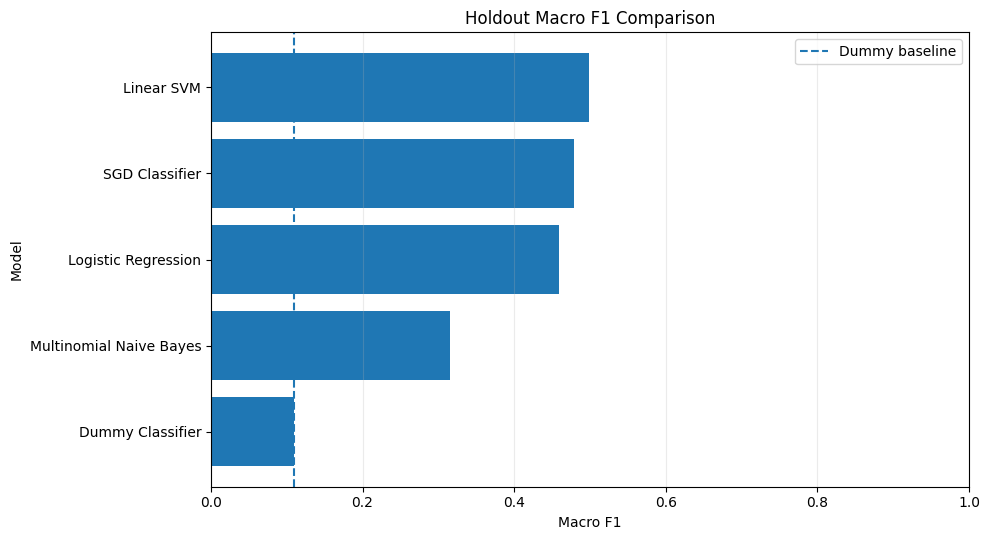

In [28]:
comparison_plot_data = holdout_model_comparison.sort_values(
    by="macro_f1",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.barh(
    comparison_plot_data["model"],
    comparison_plot_data["macro_f1"],
)

ax.axvline(
    DUMMY_MACRO_F1,
    linestyle="--",
    linewidth=1.5,
    label="Dummy baseline",
)

ax.set_title("Holdout Macro F1 Comparison")

ax.set_xlabel("Macro F1")

ax.set_ylabel("Model")

ax.set_xlim(
    0,
    1,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

plt.show()

In [15]:
show_block(
    "notebook_ui/classic_html/13_classic_classification_reports.html",
    "notebook_ui/styles/middle.css"
)

In [30]:
model_predictions = {
    "Multinomial Naive Bayes": (multinomial_nb_predictions),
    "Logistic Regression": (logistic_regression_predictions),
    "Linear SVM": (linear_svm_predictions),
    "SGD Classifier": (sgd_predictions),
}

expected_prediction_count = len(y_test)

for model_name, predictions in model_predictions.items():
    if len(predictions) != expected_prediction_count:
        raise ValueError(f"Prediction count mismatch for " f"{model_name}.")

classification_report_rows = []

for model_name, predictions in model_predictions.items():
    report = classification_report(
        y_test,
        predictions,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )

    for label in LABEL_ORDER:
        label_report = report[str(label)]

        classification_report_rows.append(
            {
                "model": model_name,
                "polarity": label,
                "label_name": (LABEL_NAMES[label]),
                "precision": (label_report["precision"]),
                "recall": (label_report["recall"]),
                "f1_score": (label_report["f1-score"]),
                "support": int(label_report["support"]),
            }
        )

per_class_classification_report = pd.DataFrame(classification_report_rows)

MODEL_DISPLAY_ORDER = [
    "Multinomial Naive Bayes",
    "Logistic Regression",
    "Linear SVM",
    "SGD Classifier",
]

per_class_classification_report["model"] = pd.Categorical(
    per_class_classification_report["model"],
    categories=MODEL_DISPLAY_ORDER,
    ordered=True,
)

per_class_classification_report = per_class_classification_report.sort_values(
    by=[
        "polarity",
        "model",
    ]
).reset_index(drop=True)

assert len(per_class_classification_report) == len(MODEL_DISPLAY_ORDER) * len(
    LABEL_ORDER
)

assert (
    per_class_classification_report["support"]
    .groupby(per_class_classification_report["polarity"])
    .nunique()
    .eq(1)
    .all()
)

display(per_class_classification_report.round(4))

,model,polarity,label_name,precision,recall,f1_score,support
0,Multinomial Naive Bayes,-2,very_negative,0.0000,0.0000,0.0000,37
1,Logistic Regression,-2,very_negative,0.3333,0.0270,0.0500,37
2,Linear SVM,-2,very_negative,0.3571,0.1351,0.1961,37
3,SGD Classifier,-2,very_negative,0.2222,0.0541,0.0870,37
4,Multinomial Naive Bayes,-1,negative,0.0000,0.0000,0.0000,275
5,Logistic Regression,-1,negative,0.3557,0.5782,0.4404,275
6,Linear SVM,-1,negative,0.4189,0.4036,0.4111,275
7,SGD Classifier,-1,negative,0.4077,0.4255,0.4164,275
8,Multinomial Naive Bayes,0,neutral,0.5981,0.8296,0.6951,992
9,Logistic Regression,0,neutral,0.6538,0.7500,0.6986,992


In [31]:
per_class_f1_comparison = per_class_classification_report.pivot(
    index=[
        "polarity",
        "label_name",
    ],
    columns="model",
    values="f1_score",
).reset_index()

per_class_f1_comparison.columns.name = None

display(per_class_f1_comparison.round(4))

,polarity,label_name,Multinomial Naive Bayes,Logistic Regression,Linear SVM,SGD Classifier
0,-2,very_negative,0.0000,0.0500,0.1961,0.0870
1,-1,negative,0.0000,0.4404,0.4111,0.4164
2,0,neutral,0.6951,0.6986,0.6961,0.6939
3,1,positive,0.5279,0.4316,0.5270,0.5274
4,2,very_positive,0.3569,0.6739,0.6634,0.6673


In [32]:
best_model_per_class = (
    per_class_classification_report.sort_values(
        by=[
            "polarity",
            "f1_score",
            "recall",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby(
        [
            "polarity",
            "label_name",
        ],
        as_index=False,
        observed=True,
    )
    .first()[
        [
            "polarity",
            "label_name",
            "model",
            "precision",
            "recall",
            "f1_score",
            "support",
        ]
    ]
)

best_model_per_class = best_model_per_class.sort_values(by="polarity").reset_index(
    drop=True
)

print("Best model for each sentiment class:")

display(best_model_per_class.round(4))

Best model for each sentiment class:


,polarity,label_name,model,precision,recall,f1_score,support
0,-2,very_negative,Linear SVM,0.3571,0.1351,0.1961,37
1,-1,negative,Logistic Regression,0.3557,0.5782,0.4404,275
2,0,neutral,Logistic Regression,0.6538,0.7500,0.6986,992
3,1,positive,Multinomial Naive Bayes,0.4637,0.6127,0.5279,834
4,2,very_positive,Logistic Regression,0.5971,0.7734,0.6739,481


In [33]:
class_difficulty_summary = (
    per_class_classification_report.groupby(
        [
            "polarity",
            "label_name",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_precision=(
            "precision",
            "mean",
        ),
        mean_recall=(
            "recall",
            "mean",
        ),
        mean_f1=(
            "f1_score",
            "mean",
        ),
        support=(
            "support",
            "first",
        ),
    )
    .sort_values(
        by="mean_f1",
        ascending=True,
    )
    .reset_index(drop=True)
)

HARDEST_CLASS_POLARITY = int(
    class_difficulty_summary.loc[
        0,
        "polarity",
    ]
)

HARDEST_CLASS_NAME = class_difficulty_summary.loc[
    0,
    "label_name",
]

HARDEST_CLASS_MEAN_F1 = float(
    class_difficulty_summary.loc[
        0,
        "mean_f1",
    ]
)

print(
    f"Hardest sentiment class: " f"{HARDEST_CLASS_POLARITY} " f"({HARDEST_CLASS_NAME})"
)

print(f"Average F1 across models: " f"{HARDEST_CLASS_MEAN_F1:.4f}")

display(class_difficulty_summary.round(4))

Hardest sentiment class: -2 (very_negative)
Average F1 across models: 0.0833


,polarity,label_name,mean_precision,mean_recall,mean_f1,support
0,-2,very_negative,0.2282,0.0541,0.0833,37
1,-1,negative,0.2956,0.3518,0.3170,275
2,1,positive,0.5574,0.4847,0.5035,834
3,2,very_positive,0.6624,0.6019,0.5904,481
4,0,neutral,0.6521,0.7513,0.6959,992


In [16]:
show_block(
    "notebook_ui/classic_html/14_classic_confusion_matrices.html",
    "notebook_ui/styles/middle.css"
)

In [35]:
expected_model_names = [
    "Multinomial Naive Bayes",
    "Logistic Regression",
    "Linear SVM",
    "SGD Classifier",
]

missing_prediction_models = [
    model_name
    for model_name in expected_model_names
    if model_name not in model_predictions
]

if missing_prediction_models:
    raise ValueError(f"Missing model predictions: " f"{missing_prediction_models}")

confusion_matrix_counts = {}

normalized_confusion_matrices = {}

for model_name in expected_model_names:
    predictions = model_predictions[model_name]

    count_matrix = confusion_matrix(
        y_test,
        predictions,
        labels=LABEL_ORDER,
    )

    normalized_matrix = confusion_matrix(
        y_test,
        predictions,
        labels=LABEL_ORDER,
        normalize="true",
    )

    count_table = pd.DataFrame(
        count_matrix,
        index=LABEL_ORDER,
        columns=LABEL_ORDER,
    )

    normalized_table = pd.DataFrame(
        normalized_matrix,
        index=LABEL_ORDER,
        columns=LABEL_ORDER,
    )

    count_table.index.name = "actual_label"

    count_table.columns.name = "predicted_label"

    normalized_table.index.name = "actual_label"

    normalized_table.columns.name = "predicted_label"

    confusion_matrix_counts[model_name] = count_table

    normalized_confusion_matrices[model_name] = normalized_table

    assert count_matrix.sum() == len(y_test)

    np.testing.assert_allclose(
        normalized_matrix.sum(axis=1),
        np.ones(len(LABEL_ORDER)),
        atol=1e-8,
    )

print("Confusion matrices created successfully.")

print(f"Analyzed models: " f"{len(confusion_matrix_counts):,}")

Confusion matrices created successfully.
Analyzed models: 4


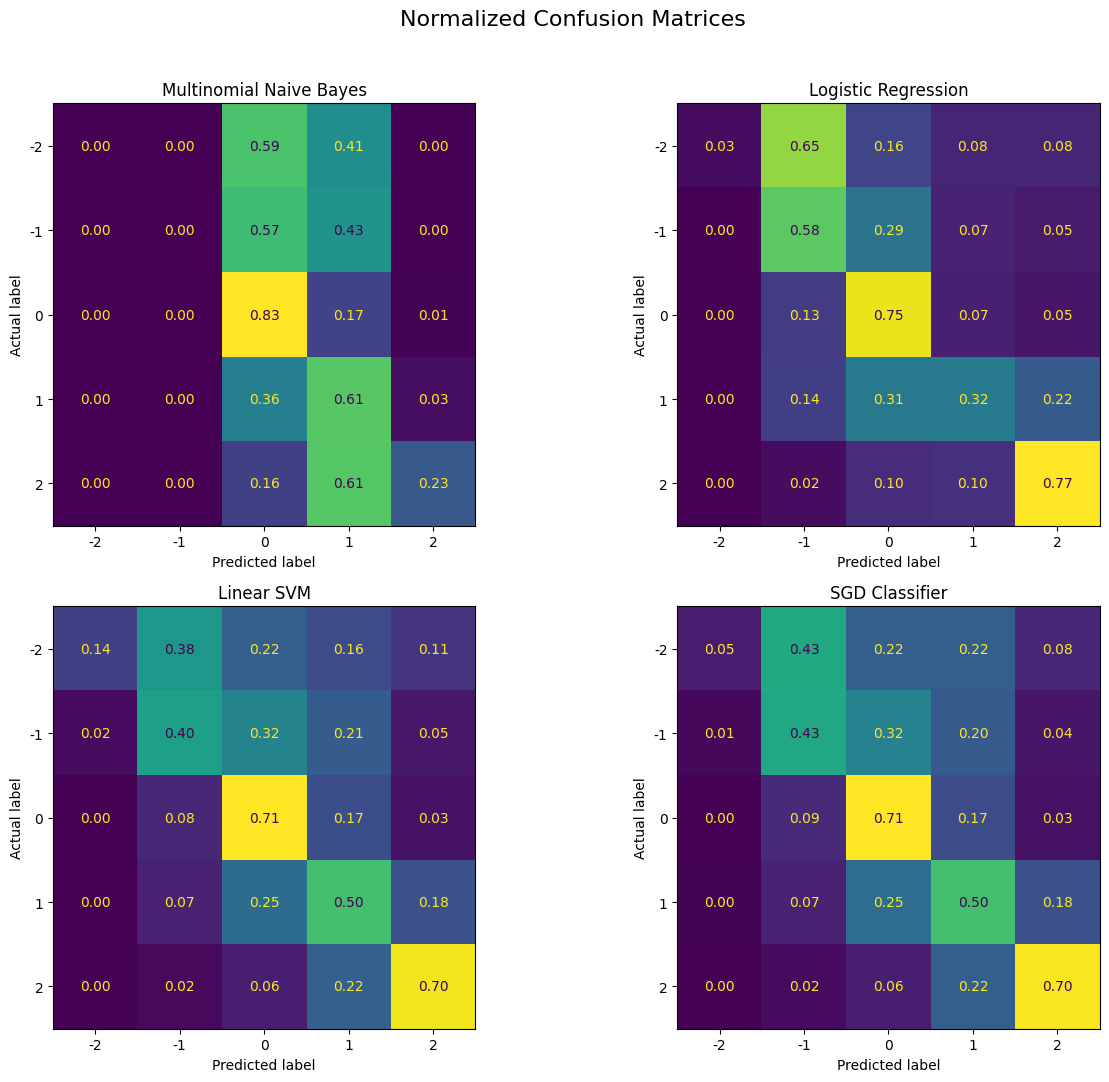

In [36]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13, 11),
)

for ax, model_name in zip(
    axes.ravel(),
    expected_model_names,
):
    normalized_matrix = normalized_confusion_matrices[model_name].to_numpy()

    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=(normalized_matrix),
        display_labels=LABEL_ORDER,
    )

    matrix_display.plot(
        ax=ax,
        colorbar=False,
        values_format=".2f",
    )

    ax.set_title(model_name)

    ax.set_xlabel("Predicted label")

    ax.set_ylabel("Actual label")

fig.suptitle(
    "Normalized Confusion Matrices",
    fontsize=16,
)

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96,
    ]
)

plt.show()

In [37]:
class_recall_rows = []

for model_name in expected_model_names:
    normalized_matrix = normalized_confusion_matrices[model_name].to_numpy()

    for label_index, label in enumerate(LABEL_ORDER):
        class_recall_rows.append(
            {
                "model": model_name,
                "polarity": label,
                "label_name": (LABEL_NAMES[label]),
                "correct_classification_rate": (
                    normalized_matrix[
                        label_index,
                        label_index,
                    ]
                ),
            }
        )

confusion_diagonal_summary = pd.DataFrame(class_recall_rows)

confusion_diagonal_comparison = confusion_diagonal_summary.pivot(
    index=[
        "polarity",
        "label_name",
    ],
    columns="model",
    values=("correct_classification_rate"),
).reset_index()

confusion_diagonal_comparison.columns.name = None

display(confusion_diagonal_comparison.round(4))

,polarity,label_name,Linear SVM,Logistic Regression,Multinomial Naive Bayes,SGD Classifier
0,-2,very_negative,0.1351,0.0270,0.0000,0.0541
1,-1,negative,0.4036,0.5782,0.0000,0.4255
2,0,neutral,0.7147,0.7500,0.8296,0.7107
3,1,positive,0.5036,0.3213,0.6127,0.5012
4,2,very_positive,0.7006,0.7734,0.2308,0.7027


In [38]:
most_common_confusion_rows = []

for model_name in expected_model_names:
    count_matrix = confusion_matrix_counts[model_name].to_numpy().copy()

    normalized_matrix = normalized_confusion_matrices[model_name].to_numpy()

    np.fill_diagonal(
        count_matrix,
        0,
    )

    actual_index, predicted_index = np.unravel_index(
        np.argmax(count_matrix),
        count_matrix.shape,
    )

    actual_label = LABEL_ORDER[actual_index]

    predicted_label = LABEL_ORDER[predicted_index]

    most_common_confusion_rows.append({
        "model":
        model_name,
        "actual_label":
        actual_label,
        "actual_label_name": (LABEL_NAMES[actual_label]),
        "predicted_label": (predicted_label),
        "predicted_label_name": (LABEL_NAMES[predicted_label]),
        "error_count":
        int(count_matrix[
            actual_index,
            predicted_index,
        ]),
        "error_rate_within_actual_class": (normalized_matrix[
            actual_index,
            predicted_index,
        ]),
    })

most_common_confusions = (pd.DataFrame(most_common_confusion_rows).sort_values(
    by="error_count",
    ascending=False,
).reset_index(drop=True))

print("Most common confusion for each model:")

display(most_common_confusions.round(4))

Most common confusion for each model:


,model,actual_label,actual_label_name,predicted_label,predicted_label_name,error_count,error_rate_within_actual_class
0,Multinomial Naive Bayes,1,positive,0,neutral,298,0.3573
1,Logistic Regression,1,positive,0,neutral,260,0.3118
2,Linear SVM,1,positive,0,neutral,211,0.2530
3,SGD Classifier,1,positive,0,neutral,211,0.2530


In [17]:
show_block(
    "notebook_ui/classic_html/15_classic_cross_validation.html",
    "notebook_ui/styles/middle.css"
)

In [40]:
CV_MODEL_ORDER = [
    "Multinomial Naive Bayes",
    "Logistic Regression",
    "Linear SVM",
    "SGD Classifier",
]

cv_model_pipelines = {
    "Multinomial Naive Bayes": (multinomial_nb_pipeline),
    "Logistic Regression": (logistic_regression_pipeline),
    "Linear SVM": (linear_svm_pipeline),
    "SGD Classifier": (sgd_classifier_pipeline),
}

missing_cv_models = [
    model_name for model_name in CV_MODEL_ORDER if model_name not in cv_model_pipelines
]

if missing_cv_models:
    raise ValueError(f"Missing cross-validation models: " f"{missing_cv_models}")

MINIMUM_TRAIN_CLASS_SIZE = int(y_train.value_counts().min())

if MINIMUM_TRAIN_CLASS_SIZE < CV_FOLDS:
    raise ValueError(
        "The smallest training class has fewer " "samples than the number of CV folds."
    )

cross_validation_splitter = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

CV_N_JOBS = -1

print(f"Cross-validation folds: " f"{CV_FOLDS}")

print(f"Minimum training class size: " f"{MINIMUM_TRAIN_CLASS_SIZE:,}")

print(f"Models to evaluate: " f"{len(CV_MODEL_ORDER)}")

print("Cross-validation configuration is ready.")

Cross-validation folds: 10
Minimum training class size: 147
Models to evaluate: 4
Cross-validation configuration is ready.


In [41]:
cross_validation_scoring = {
    "accuracy": "accuracy",
    "macro_precision": make_scorer(
        precision_score,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": make_scorer(
        recall_score,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        labels=LABEL_ORDER,
        average="weighted",
        zero_division=0,
    ),
    "cohen_kappa": make_scorer(cohen_kappa_score),
}

print("Cross-validation scoring metrics " "created successfully.")

Cross-validation scoring metrics created successfully.


In [42]:
cross_validation_raw_results = {}

cross_validation_fold_rows = []

for model_name in CV_MODEL_ORDER:
    print(f"Running cross-validation for: " f"{model_name}")

    model_cv_start_time = time.perf_counter()

    cv_result = cross_validate(
        estimator=(cv_model_pipelines[model_name]),
        X=X_train,
        y=y_train,
        cv=cross_validation_splitter,
        scoring=cross_validation_scoring,
        n_jobs=CV_N_JOBS,
        return_train_score=False,
        error_score="raise",
    )

    model_cv_elapsed_time = time.perf_counter() - model_cv_start_time

    cross_validation_raw_results[model_name] = cv_result

    for fold_index in range(CV_FOLDS):
        cross_validation_fold_rows.append(
            {
                "model": model_name,
                "fold": fold_index + 1,
                "accuracy": (cv_result["test_accuracy"][fold_index]),
                "macro_precision": (cv_result["test_macro_precision"][fold_index]),
                "macro_recall": (cv_result["test_macro_recall"][fold_index]),
                "macro_f1": (cv_result["test_macro_f1"][fold_index]),
                "weighted_f1": (cv_result["test_weighted_f1"][fold_index]),
                "cohen_kappa": (cv_result["test_cohen_kappa"][fold_index]),
                "fit_time_seconds": (cv_result["fit_time"][fold_index]),
                "score_time_seconds": (cv_result["score_time"][fold_index]),
            }
        )

    print(f"Completed: {model_name}")

    print(f"Elapsed time: " f"{model_cv_elapsed_time:.2f} seconds")

cross_validation_fold_results = pd.DataFrame(cross_validation_fold_rows)

assert len(cross_validation_fold_results) == len(CV_MODEL_ORDER) * CV_FOLDS

print("Cross-validation completed successfully.")

print(f"Total fold results: " f"{len(cross_validation_fold_results):,}")

display(cross_validation_fold_results.round(4))

Running cross-validation for: Multinomial Naive Bayes
Completed: Multinomial Naive Bayes
Elapsed time: 29.49 seconds
Running cross-validation for: Logistic Regression
Completed: Logistic Regression
Elapsed time: 518.86 seconds
Running cross-validation for: Linear SVM
Completed: Linear SVM
Elapsed time: 15.93 seconds
Running cross-validation for: SGD Classifier
Completed: SGD Classifier
Elapsed time: 14.28 seconds
Cross-validation completed successfully.
Total fold results: 40


,model,fold,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,cohen_kappa,fit_time_seconds,score_time_seconds
0,Multinomial Naive Bayes,1,0.5305,0.3506,0.3191,0.2982,0.4730,0.2841,2.8683,0.2244
1,Multinomial Naive Bayes,2,0.5277,0.3503,0.3174,0.2978,0.4711,0.2786,3.1862,0.3313
2,Multinomial Naive Bayes,3,0.5401,0.3781,0.3265,0.3079,0.4852,0.2988,3.1147,0.3064
3,Multinomial Naive Bayes,4,0.5468,0.3726,0.3313,0.3127,0.4918,0.3095,3.4297,0.3550
4,Multinomial Naive Bayes,5,0.5649,0.4868,0.3478,0.3350,0.5143,0.3379,3.4203,0.2945
5,Multinomial Naive Bayes,6,0.5377,0.5707,0.3209,0.2979,0.4769,0.2937,3.6246,0.3575
6,Multinomial Naive Bayes,7,0.5654,0.3900,0.3416,0.3212,0.5084,0.3385,3.7637,0.3495
7,Multinomial Naive Bayes,8,0.5425,0.3641,0.3273,0.3087,0.4864,0.3014,3.3240,0.3007
8,Multinomial Naive Bayes,9,0.5454,0.3705,0.3319,0.3136,0.4921,0.3094,3.5053,0.2425
9,Multinomial Naive Bayes,10,0.5339,0.3714,0.3223,0.3027,0.4785,0.2900,2.7534,0.1906


In [43]:
cross_validation_summary = cross_validation_fold_results.groupby(
    "model",
    as_index=False,
    observed=True,
).agg(
    mean_accuracy=(
        "accuracy",
        "mean",
    ),
    std_accuracy=(
        "accuracy",
        "std",
    ),
    mean_macro_precision=(
        "macro_precision",
        "mean",
    ),
    std_macro_precision=(
        "macro_precision",
        "std",
    ),
    mean_macro_recall=(
        "macro_recall",
        "mean",
    ),
    std_macro_recall=(
        "macro_recall",
        "std",
    ),
    mean_macro_f1=(
        "macro_f1",
        "mean",
    ),
    std_macro_f1=(
        "macro_f1",
        "std",
    ),
    mean_weighted_f1=(
        "weighted_f1",
        "mean",
    ),
    std_weighted_f1=(
        "weighted_f1",
        "std",
    ),
    mean_cohen_kappa=(
        "cohen_kappa",
        "mean",
    ),
    std_cohen_kappa=(
        "cohen_kappa",
        "std",
    ),
    mean_fit_time_seconds=(
        "fit_time_seconds",
        "mean",
    ),
    mean_score_time_seconds=(
        "score_time_seconds",
        "mean",
    ),
)

In [44]:
cross_validation_summary = (
    cross_validation_summary
    .sort_values(
        by=[
            "mean_macro_f1",
            "mean_weighted_f1",
            "mean_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

cross_validation_summary.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            cross_validation_summary
        ) + 1,
    ),
)

BEST_CV_MODEL_NAME = (
    cross_validation_summary.loc[
        0,
        "model",
    ]
)

BEST_CV_MACRO_F1 = float(
    cross_validation_summary.loc[
        0,
        "mean_macro_f1",
    ]
)

BEST_CV_MACRO_F1_STD = float(
    cross_validation_summary.loc[
        0,
        "std_macro_f1",
    ]
)

BEST_CV_WEIGHTED_F1 = float(
    cross_validation_summary.loc[
        0,
        "mean_weighted_f1",
    ]
)

BEST_CV_ACCURACY = float(
    cross_validation_summary.loc[
        0,
        "mean_accuracy",
    ]
)

print(
    f"Best cross-validation model: "
    f"{BEST_CV_MODEL_NAME}"
)

print(
    f"Mean Macro F1: "
    f"{BEST_CV_MACRO_F1:.4f}"
)

print(
    f"Macro F1 standard deviation: "
    f"{BEST_CV_MACRO_F1_STD:.4f}"
)

print(
    f"Mean Weighted F1: "
    f"{BEST_CV_WEIGHTED_F1:.4f}"
)

print(
    f"Mean Accuracy: "
    f"{BEST_CV_ACCURACY:.4f}"
)

display(
    cross_validation_summary
    .round(4)
)

Best cross-validation model: Linear SVM
Mean Macro F1: 0.4983
Macro F1 standard deviation: 0.0199
Mean Weighted F1: 0.6097
Mean Accuracy: 0.6143


,rank,model,mean_accuracy,std_accuracy,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_macro_f1,std_macro_f1,mean_weighted_f1,std_weighted_f1,mean_cohen_kappa,std_cohen_kappa,mean_fit_time_seconds,mean_score_time_seconds
0,1,Linear SVM,0.6143,0.0135,0.5199,0.0326,0.4949,0.0182,0.4983,0.0199,0.6097,0.0139,0.4554,0.0198,5.1422,0.3288
1,2,SGD Classifier,0.6135,0.0145,0.5219,0.0709,0.4907,0.0234,0.4908,0.0283,0.6084,0.0154,0.4547,0.0207,4.6212,0.3321
2,3,Logistic Regression,0.5372,0.1350,0.4752,0.0251,0.4759,0.0767,0.4355,0.0879,0.5452,0.1194,0.3935,0.1072,181.8993,0.3604
3,4,Multinomial Naive Bayes,0.5435,0.0129,0.4005,0.0714,0.3286,0.0099,0.3096,0.0118,0.4878,0.0144,0.3042,0.0205,3.2990,0.2952


In [45]:
HOLDOUT_CV_SELECTION_AGREEMENT = (
    BEST_HOLDOUT_MODEL_NAME
    == BEST_CV_MODEL_NAME
)

selection_comparison = pd.DataFrame(
    {
        "selection_method": [
            "Holdout test",
            "10-fold cross-validation",
        ],
        "selected_model": [
            BEST_HOLDOUT_MODEL_NAME,
            BEST_CV_MODEL_NAME,
        ],
        "macro_f1": [
            BEST_HOLDOUT_MACRO_F1,
            BEST_CV_MACRO_F1,
        ],
    }
)

print(
    f"Holdout and CV agreement: "
    f"{HOLDOUT_CV_SELECTION_AGREEMENT}"
)

display(
    selection_comparison
    .round(4)
)

Holdout and CV agreement: True


,selection_method,selected_model,macro_f1
0,Holdout test,Linear SVM,0.4987
1,10-fold cross-validation,Linear SVM,0.4983


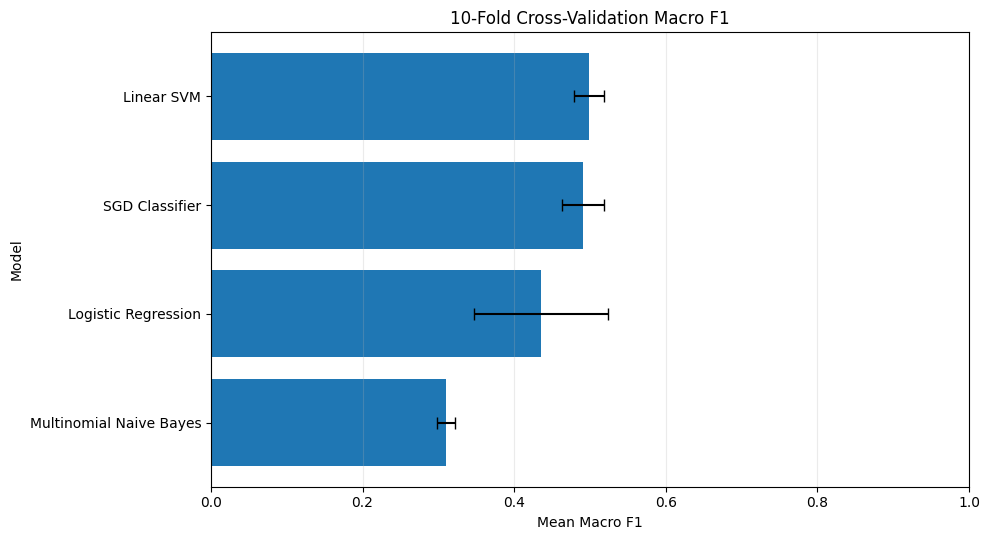

In [46]:
cross_validation_plot_data = cross_validation_summary.sort_values(
    by="mean_macro_f1",
    ascending=True,
)

cross_validation_figure, ax = plt.subplots(figsize=(10, 5.5))

ax.barh(
    cross_validation_plot_data["model"],
    cross_validation_plot_data["mean_macro_f1"],
    xerr=(cross_validation_plot_data["std_macro_f1"]),
    capsize=4,
)

ax.set_title("10-Fold Cross-Validation Macro F1")

ax.set_xlabel("Mean Macro F1")

ax.set_ylabel("Model")

ax.set_xlim(
    0,
    1,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

cross_validation_figure.tight_layout()

plt.show()

In [18]:
show_block(
    "notebook_ui/classic_html/16_classic_error_analysis.html",
    "notebook_ui/styles/middle.css"
)

In [48]:
required_error_analysis_objects = {
    "BEST_CV_MODEL_NAME": BEST_CV_MODEL_NAME,
    "model_predictions": model_predictions,
    "X_test": X_test,
    "y_test": y_test,
}

if BEST_CV_MODEL_NAME not in model_predictions:
    raise ValueError(f"Predictions are not available for " f"{BEST_CV_MODEL_NAME}.")

selected_model_predictions = np.asarray(model_predictions[BEST_CV_MODEL_NAME])

actual_test_labels = np.asarray(y_test)

test_texts = np.asarray(X_test.astype(str))

if not (len(test_texts) == len(actual_test_labels) == len(selected_model_predictions)):
    raise ValueError(
        "The number of texts, actual labels, " "and predictions does not match."
    )

error_analysis_table = pd.DataFrame(
    {
        "dataset_index": (X_test.index.to_numpy()),
        "text": test_texts,
        "actual_label": (actual_test_labels),
        "predicted_label": (selected_model_predictions),
    }
)

error_analysis_table["actual_label_name"] = error_analysis_table["actual_label"].map(
    LABEL_NAMES
)

error_analysis_table["predicted_label_name"] = error_analysis_table[
    "predicted_label"
].map(LABEL_NAMES)

error_analysis_table["is_correct"] = (
    error_analysis_table["actual_label"] == error_analysis_table["predicted_label"]
)

error_analysis_table["label_difference"] = (
    error_analysis_table["predicted_label"] - error_analysis_table["actual_label"]
)

error_analysis_table["label_distance"] = error_analysis_table["label_difference"].abs()

error_analysis_table["character_count"] = error_analysis_table["text"].str.len()

error_analysis_table["word_count"] = error_analysis_table["text"].str.split().str.len()

print(f"Selected model: " f"{BEST_CV_MODEL_NAME}")

print(f"Analyzed test samples: " f"{len(error_analysis_table):,}")

display(error_analysis_table.head())

Selected model: Linear SVM
Analyzed test samples: 2,619


,dataset_index,text,actual_label,predicted_label,actual_label_name,predicted_label_name,is_correct,label_difference,label_distance,character_count,word_count
0,85,مود Adv (Advanced) قابلیت‌های خیلی خوبی مثل ای...,1,2,positive,very_positive,False,1,1,116,22
1,2771,رزولوشن صفحه اش پایینه در حالی که تبلت های 7 ا...,-1,-1,negative,negative,True,0,0,96,23
2,11539,نکته جالب در مورد Nexus 4 این است که این گوشی ...,1,1,positive,positive,True,0,0,144,30
3,7610,در تست‌های سخت افزاری انجام شده بر روی این گوش...,0,0,neutral,neutral,True,0,0,182,37
4,193,واقعا نسبت به قیمتش ارزش داشت (البته اون موقع ...,1,-1,positive,negative,False,-2,2,72,15


In [49]:
error_analysis_table["error_severity"] = np.select(
    condlist=[
        error_analysis_table["label_distance"].eq(0),
        error_analysis_table["label_distance"].eq(1),
        error_analysis_table["label_distance"].ge(2),
    ],
    choicelist=[
        "correct",
        "adjacent_class_error",
        "distant_class_error",
    ],
    default="unknown",
)

error_analysis_table["error_direction"] = np.select(
    condlist=[
        error_analysis_table["label_difference"].eq(0),
        error_analysis_table["label_difference"].gt(0),
        error_analysis_table["label_difference"].lt(0),
    ],
    choicelist=[
        "correct",
        "predicted_more_positive",
        "predicted_more_negative",
    ],
    default="unknown",
)

misclassified_samples = (
    error_analysis_table.loc[~error_analysis_table["is_correct"]]
    .copy()
    .reset_index(drop=True)
)

print(f"Misclassified samples: " f"{len(misclassified_samples):,}")

Misclassified samples: 1,037


In [50]:
total_test_samples = len(error_analysis_table)

correct_prediction_count = int(error_analysis_table["is_correct"].sum())

incorrect_prediction_count = int((~error_analysis_table["is_correct"]).sum())

adjacent_error_count = int(
    error_analysis_table["error_severity"].eq("adjacent_class_error").sum()
)

distant_error_count = int(
    error_analysis_table["error_severity"].eq("distant_class_error").sum()
)

error_overview = pd.DataFrame(
    {
        "metric": [
            "selected_model",
            "total_test_samples",
            "correct_predictions",
            "incorrect_predictions",
            "accuracy",
            "error_rate",
            "adjacent_class_errors",
            "distant_class_errors",
        ],
        "value": [
            BEST_CV_MODEL_NAME,
            total_test_samples,
            correct_prediction_count,
            incorrect_prediction_count,
            (correct_prediction_count / total_test_samples),
            (incorrect_prediction_count / total_test_samples),
            adjacent_error_count,
            distant_error_count,
        ],
    }
)

display(error_overview)

,metric,value
0,selected_model,Linear SVM
1,total_test_samples,2619
2,correct_predictions,1582
3,incorrect_predictions,1037
4,accuracy,0.604047
5,error_rate,0.395953
6,adjacent_class_errors,819
7,distant_class_errors,218


In [51]:
error_severity_summary = (
    error_analysis_table["error_severity"]
    .value_counts()
    .rename_axis("error_severity")
    .reset_index(name="count")
)

error_severity_summary["percentage"] = (
    error_severity_summary["count"] / len(error_analysis_table) * 100
)

error_direction_summary = (
    misclassified_samples["error_direction"]
    .value_counts()
    .rename_axis("error_direction")
    .reset_index(name="count")
)

error_direction_summary["percentage_of_errors"] = (
    error_direction_summary["count"] / len(misclassified_samples) * 100
)

print("Error severity summary:")

display(error_severity_summary.round(2))

print("Error direction summary:")

display(error_direction_summary.round(2))

Error severity summary:


,error_severity,count,percentage
0,correct,1582,60.40
1,adjacent_class_error,819,31.27
2,distant_class_error,218,8.32


Error direction summary:


,error_direction,count,percentage_of_errors
0,predicted_more_positive,542,52.27
1,predicted_more_negative,495,47.73


In [52]:
class_error_summary = error_analysis_table.groupby(
    [
        "actual_label",
        "actual_label_name",
    ],
    as_index=False,
    observed=True,
).agg(
    support=(
        "is_correct",
        "size",
    ),
    correct_count=(
        "is_correct",
        "sum",
    ),
    mean_label_distance=(
        "label_distance",
        "mean",
    ),
    mean_character_count=(
        "character_count",
        "mean",
    ),
    mean_word_count=(
        "word_count",
        "mean",
    ),
)

class_error_summary["correct_count"] = class_error_summary["correct_count"].astype(int)

class_error_summary["error_count"] = (
    class_error_summary["support"] - class_error_summary["correct_count"]
)

class_error_summary["accuracy"] = (
    class_error_summary["correct_count"] / class_error_summary["support"]
)

class_error_summary["error_rate"] = (
    class_error_summary["error_count"] / class_error_summary["support"]
)

class_error_summary = class_error_summary.sort_values(
    by=[
        "error_rate",
        "actual_label",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

HARDEST_ERROR_CLASS_LABEL = int(
    class_error_summary.loc[
        0,
        "actual_label",
    ]
)

HARDEST_ERROR_CLASS_NAME = class_error_summary.loc[
    0,
    "actual_label_name",
]

HARDEST_ERROR_CLASS_RATE = float(
    class_error_summary.loc[
        0,
        "error_rate",
    ]
)

print(
    f"Class with highest error rate: "
    f"{HARDEST_ERROR_CLASS_LABEL} "
    f"({HARDEST_ERROR_CLASS_NAME})"
)

print(f"Error rate: " f"{HARDEST_ERROR_CLASS_RATE:.4f}")

display(class_error_summary.round(4))

Class with highest error rate: -2 (very_negative)
Error rate: 0.8649


,actual_label,actual_label_name,support,correct_count,mean_label_distance,mean_character_count,mean_word_count,error_count,accuracy,error_rate
0,-2,very_negative,37,5,1.7297,151.2162,31.8649,32,0.1351,0.8649
1,-1,negative,275,111,0.8982,108.4036,22.7891,164,0.4036,0.5964
2,1,positive,834,420,0.5647,111.6007,23.1175,414,0.5036,0.4964
3,2,very_positive,481,337,0.3971,104.2516,21.4262,144,0.7006,0.2994
4,0,neutral,992,709,0.3216,92.4032,18.8659,283,0.7147,0.2853


In [53]:
confusion_pair_summary = misclassified_samples.groupby(
    [
        "actual_label",
        "actual_label_name",
        "predicted_label",
        "predicted_label_name",
    ],
    as_index=False,
    observed=True,
).agg(
    error_count=(
        "text",
        "size",
    ),
    mean_character_count=(
        "character_count",
        "mean",
    ),
    mean_word_count=(
        "word_count",
        "mean",
    ),
)

confusion_pair_summary["percentage_of_all_errors"] = (
    confusion_pair_summary["error_count"] / len(misclassified_samples) * 100
)

confusion_pair_summary["label_distance"] = (
    confusion_pair_summary["predicted_label"] - confusion_pair_summary["actual_label"]
).abs()

confusion_pair_summary = confusion_pair_summary.sort_values(
    by=[
        "error_count",
        "label_distance",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

MOST_COMMON_ERROR_ACTUAL_LABEL = int(
    confusion_pair_summary.loc[
        0,
        "actual_label",
    ]
)

MOST_COMMON_ERROR_PREDICTED_LABEL = int(
    confusion_pair_summary.loc[
        0,
        "predicted_label",
    ]
)

MOST_COMMON_ERROR_COUNT = int(
    confusion_pair_summary.loc[
        0,
        "error_count",
    ]
)

print("Most common confusion pairs:")

display(confusion_pair_summary.head(15).round(2))

Most common confusion pairs:


,actual_label,actual_label_name,predicted_label,predicted_label_name,error_count,mean_character_count,mean_word_count,percentage_of_all_errors,label_distance
0,1,positive,0,neutral,211,104.05,21.30,20.35,1
1,0,neutral,1,positive,171,117.09,24.28,16.49,1
2,1,positive,2,very_positive,147,97.39,19.97,14.18,1
3,2,very_positive,1,positive,106,116.56,24.18,10.22,1
4,-1,negative,0,neutral,88,95.26,20.02,8.49,1
5,0,neutral,-1,negative,76,111.87,23.16,7.33,1
6,-1,negative,1,positive,57,123.96,26.04,5.50,2
7,1,positive,-1,negative,55,128.42,27.22,5.30,2
8,0,neutral,2,very_positive,34,150.47,30.38,3.28,2
9,2,very_positive,0,neutral,29,145.10,30.00,2.80,2


In [54]:
ERROR_EXAMPLES_PER_PAIR = 3

shuffled_error_samples = misclassified_samples.sample(
    frac=1,
    random_state=RANDOM_STATE,
)

error_examples = (
    shuffled_error_samples.groupby(
        [
            "actual_label",
            "predicted_label",
        ],
        group_keys=False,
        observed=True,
    )
    .head(ERROR_EXAMPLES_PER_PAIR)
    .sort_values(
        by=[
            "label_distance",
            "actual_label",
            "predicted_label",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )[
        [
            "dataset_index",
            "text",
            "actual_label",
            "actual_label_name",
            "predicted_label",
            "predicted_label_name",
            "label_distance",
            "error_direction",
            "character_count",
            "word_count",
        ]
    ]
    .reset_index(drop=True)
)

print("Sample misclassified texts:")

display(error_examples.head(30))

Sample misclassified texts:


,dataset_index,text,actual_label,actual_label_name,predicted_label,predicted_label_name,label_distance,error_direction,character_count,word_count
0,9687,از هر لحاظ بهترینه، سخت افزار قدرتمندش حتما حس...,-2,very_negative,2,very_positive,4,predicted_more_positive,124,27
1,9244,کسانی که پیش از این کاربر دوربین های 500D، 550...,-2,very_negative,2,very_positive,4,predicted_more_positive,232,50
2,7235,این در حالیه که با این پول میتونید هم یه تبلت ...,-2,very_negative,2,very_positive,4,predicted_more_positive,83,20
3,11818,سلام این گوشیو ده روزه که خریدم ولی وقتی دماش ...,-2,very_negative,1,positive,3,predicted_more_positive,167,34
4,9636,تا دیروز S II مسخره میکردم چون که خیلی سبک بود...,-2,very_negative,1,positive,3,predicted_more_positive,77,16
5,9704,1- بهترین دوربینو نداره PURE VIEW و LUMIA دارن...,-2,very_negative,1,positive,3,predicted_more_positive,424,91
6,8515,کیفیت عکس‌ها کاملا ابتدایی است.,-1,negative,2,very_positive,3,predicted_more_positive,31,5
7,6886,من به نظرم نوت 2 خیلی بیشتر از این می ارزه چرا...,-1,negative,2,very_positive,3,predicted_more_positive,166,39
8,7986,دوربین خیلی خوبیه اما کیفیت عکس fz150 از این ب...,-1,negative,2,very_positive,3,predicted_more_positive,50,10
9,6915,در مورد وان ایکس هم همین حرف ها گفته می شد که ...,1,positive,-2,very_negative,3,predicted_more_negative,155,35


In [55]:
severe_error_examples = (
    misclassified_samples.sort_values(
        by=[
            "label_distance",
            "character_count",
        ],
        ascending=[
            False,
            False,
        ],
    )[
        [
            "dataset_index",
            "text",
            "actual_label",
            "actual_label_name",
            "predicted_label",
            "predicted_label_name",
            "label_distance",
            "error_direction",
        ]
    ]
    .head(20)
    .reset_index(drop=True)
)

print("Most severe classification errors:")

display(severe_error_examples)

Most severe classification errors:


,dataset_index,text,actual_label,actual_label_name,predicted_label,predicted_label_name,label_distance,error_direction
0,9244,کسانی که پیش از این کاربر دوربین های 500D، 550...,-2,very_negative,2,very_positive,4,predicted_more_positive
1,9687,از هر لحاظ بهترینه، سخت افزار قدرتمندش حتما حس...,-2,very_negative,2,very_positive,4,predicted_more_positive
2,7235,این در حالیه که با این پول میتونید هم یه تبلت ...,-2,very_negative,2,very_positive,4,predicted_more_positive
3,7315,سرعت خیلی پایینی داره.,-2,very_negative,2,very_positive,4,predicted_more_positive
4,9704,1- بهترین دوربینو نداره PURE VIEW و LUMIA دارن...,-2,very_negative,1,positive,3,predicted_more_positive
5,8532,یکی از نقاط ضعف این دوربین، ضبط نشدن صدا هنگام...,-2,very_negative,1,positive,3,predicted_more_positive
6,2358,اپل با وجود سیستم عامل عالی اش همیشه خوب بوده ...,-1,negative,2,very_positive,3,predicted_more_positive
7,12443,سلام من مدتی است که این گوشی را دارم بسیار گوش...,-1,negative,2,very_positive,3,predicted_more_positive
8,6366,در قلب Galaxy S II یک پردازنده‌ی بسیار قدرتمند...,-1,negative,2,very_positive,3,predicted_more_positive
9,2000,به نظر من اپل دیگه دوره اش سر رسیده اگر قرار ب...,-1,negative,2,very_positive,3,predicted_more_positive


In [19]:
show_block(
    "notebook_ui/classic_html/17_classic_save_results.html",
    "notebook_ui/styles/middle.css"
)

All required output objects are available.
Selected model: Linear SVM
Saved main tables: 20
Confusion matrix tables saved successfully.
Saved trained models: 4
Best model saved: D:\Bachelor Project\PersianSentimentProject\outputs\models\03_classic_models\best_classic_model.joblib
Model metadata saved successfully.


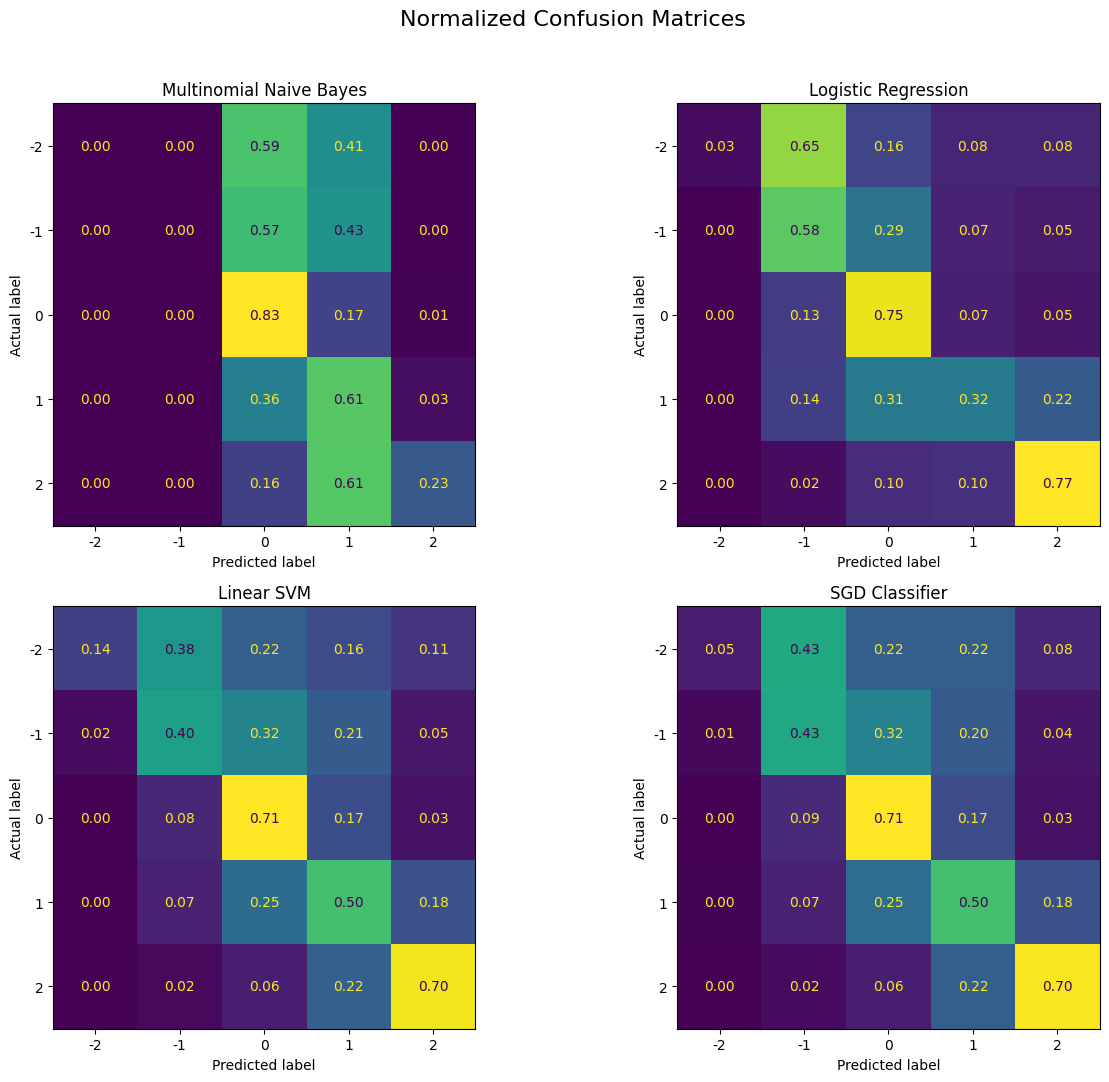

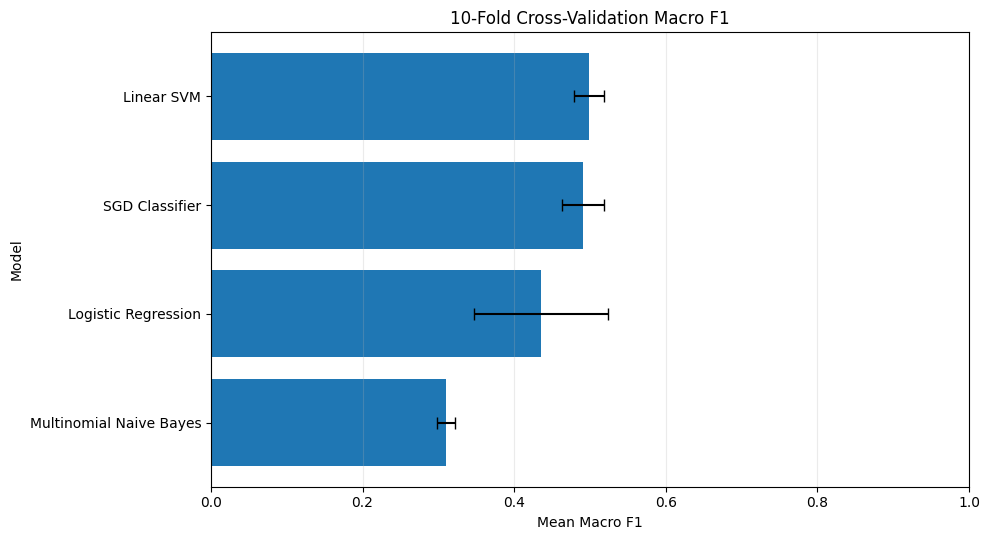

Saved artifacts: 36


,category,file_name,absolute_path,size_kb
0,figure,cross_validation_macro_f1.png,D:\Bachelor Project\PersianSentimentProject\ou...,80.22
1,figure,normalized_confusion_matrices.png,D:\Bachelor Project\PersianSentimentProject\ou...,329.18
2,metadata,classic_model_metadata.json,D:\Bachelor Project\PersianSentimentProject\ou...,1.02
3,model,linear_svm.joblib,D:\Bachelor Project\PersianSentimentProject\ou...,1318.56
4,model,logistic_regression.joblib,D:\Bachelor Project\PersianSentimentProject\ou...,871.10
5,model,multinomial_naive_bayes.joblib,D:\Bachelor Project\PersianSentimentProject\ou...,1192.15
6,model,sgd_classifier.joblib,D:\Bachelor Project\PersianSentimentProject\ou...,815.72
7,selected_model,best_classic_model.joblib,D:\Bachelor Project\PersianSentimentProject\ou...,1318.56
8,table,best_model_per_class.csv,D:\Bachelor Project\PersianSentimentProject\ou...,0.51
9,table,class_difficulty_summary.csv,D:\Bachelor Project\PersianSentimentProject\ou...,0.43


All final outputs were saved successfully.
Selected classic model: Linear SVM
Mean CV Macro F1: 0.4983
Model file: D:\Bachelor Project\PersianSentimentProject\outputs\models\03_classic_models\best_classic_model.joblib
Tables directory: D:\Bachelor Project\PersianSentimentProject\outputs\tables\03_classic_models
Figures directory: D:\Bachelor Project\PersianSentimentProject\outputs\figures\03_classic_models
Models directory: D:\Bachelor Project\PersianSentimentProject\outputs\models\03_classic_models


In [57]:
# Validate outputs
required_output_objects = [
    "environment_summary",
    "holdout_model_comparison",
    "per_class_classification_report",
    "per_class_f1_comparison",
    "best_model_per_class",
    "class_difficulty_summary",
    "confusion_matrix_counts",
    "normalized_confusion_matrices",
    "confusion_diagonal_comparison",
    "most_common_confusions",
    "cross_validation_fold_results",
    "cross_validation_summary",
    "selection_comparison",
    "error_analysis_table",
    "misclassified_samples",
    "error_overview",
    "error_severity_summary",
    "error_direction_summary",
    "class_error_summary",
    "confusion_pair_summary",
    "error_examples",
    "severe_error_examples",
    "BEST_CV_MODEL_NAME",
    "BEST_CV_MACRO_F1",
    "BEST_CV_MACRO_F1_STD",
    "BEST_HOLDOUT_MODEL_NAME",
    "BEST_HOLDOUT_MACRO_F1",
    "HOLDOUT_CV_SELECTION_AGREEMENT",
]

missing_output_objects = [
    object_name
    for object_name in required_output_objects
    if object_name not in globals()
]

if missing_output_objects:
    raise NameError(
        f"Missing required output objects: "
        f"{missing_output_objects}"
    )

print(
    "All required output objects are available."
)

print(
    f"Selected model: "
    f"{BEST_CV_MODEL_NAME}"
)


# Define model files
MODEL_FILE_STEMS = {
    "Multinomial Naive Bayes": (
        "multinomial_naive_bayes"
    ),
    "Logistic Regression": (
        "logistic_regression"
    ),
    "Linear SVM": (
        "linear_svm"
    ),
    "SGD Classifier": (
        "sgd_classifier"
    ),
}

trained_model_pipelines = {
    "Multinomial Naive Bayes": (
        multinomial_nb_pipeline
    ),
    "Logistic Regression": (
        logistic_regression_pipeline
    ),
    "Linear SVM": (
        linear_svm_pipeline
    ),
    "SGD Classifier": (
        sgd_classifier_pipeline
    ),
}

if BEST_CV_MODEL_NAME not in (
    trained_model_pipelines
):
    raise ValueError(
        f"Selected model pipeline is missing: "
        f"{BEST_CV_MODEL_NAME}"
    )


# Track saved files
saved_artifact_rows = []


def register_saved_artifact(
    file_path,
    category,
):
    resolved_path = (
        file_path.resolve()
    )

    if not resolved_path.is_file():
        raise FileNotFoundError(
            f"Saved file not found: "
            f"{resolved_path}"
        )

    saved_artifact_rows.append(
        {
            "category": category,
            "file_name": file_path.name,
            "absolute_path": str(
                resolved_path
            ),
            "size_kb": (
                resolved_path.stat().st_size
                / 1024
            ),
        }
    )


def save_csv_table(
    table,
    file_name,
):
    file_path = (
        CLASSIC_TABLES_DIR
        / file_name
    )

    table.to_csv(
        file_path,
        index=False,
        encoding="utf-8-sig",
    )

    register_saved_artifact(
        file_path,
        "table",
    )

    return file_path


# Save main tables
output_tables = {
    "environment_summary.csv": (
        environment_summary
    ),
    "holdout_model_comparison.csv": (
        holdout_model_comparison
    ),
    "per_class_classification_report.csv": (
        per_class_classification_report
    ),
    "per_class_f1_comparison.csv": (
        per_class_f1_comparison
    ),
    "best_model_per_class.csv": (
        best_model_per_class
    ),
    "class_difficulty_summary.csv": (
        class_difficulty_summary
    ),
    "confusion_diagonal_comparison.csv": (
        confusion_diagonal_comparison
    ),
    "most_common_confusions.csv": (
        most_common_confusions
    ),
    "cross_validation_fold_results.csv": (
        cross_validation_fold_results
    ),
    "cross_validation_summary.csv": (
        cross_validation_summary
    ),
    "selection_comparison.csv": (
        selection_comparison
    ),
    "error_analysis_table.csv": (
        error_analysis_table
    ),
    "misclassified_samples.csv": (
        misclassified_samples
    ),
    "error_overview.csv": (
        error_overview
    ),
    "error_severity_summary.csv": (
        error_severity_summary
    ),
    "error_direction_summary.csv": (
        error_direction_summary
    ),
    "class_error_summary.csv": (
        class_error_summary
    ),
    "confusion_pair_summary.csv": (
        confusion_pair_summary
    ),
    "error_examples.csv": (
        error_examples
    ),
    "severe_error_examples.csv": (
        severe_error_examples
    ),
}

for file_name, output_table in (
    output_tables.items()
):
    save_csv_table(
        output_table,
        file_name,
    )

print(
    f"Saved main tables: "
    f"{len(output_tables):,}"
)


# Save confusion matrices
for model_name in MODEL_FILE_STEMS:
    model_file_stem = (
        MODEL_FILE_STEMS[
            model_name
        ]
    )

    count_matrix_path = (
        CLASSIC_TABLES_DIR
        / (
            f"{model_file_stem}"
            "_confusion_matrix_counts.csv"
        )
    )

    normalized_matrix_path = (
        CLASSIC_TABLES_DIR
        / (
            f"{model_file_stem}"
            "_confusion_matrix_normalized.csv"
        )
    )

    confusion_matrix_counts[
        model_name
    ].to_csv(
        count_matrix_path,
        encoding="utf-8-sig",
    )

    normalized_confusion_matrices[
        model_name
    ].to_csv(
        normalized_matrix_path,
        encoding="utf-8-sig",
    )

    register_saved_artifact(
        count_matrix_path,
        "table",
    )

    register_saved_artifact(
        normalized_matrix_path,
        "table",
    )

print(
    "Confusion matrix tables saved successfully."
)


# Save trained models
for model_name, model_pipeline in (
    trained_model_pipelines.items()
):
    model_file_stem = (
        MODEL_FILE_STEMS[
            model_name
        ]
    )

    model_path = (
        CLASSIC_MODELS_DIR
        / f"{model_file_stem}.joblib"
    )

    joblib.dump(
        model_pipeline,
        model_path,
        compress=3,
    )

    register_saved_artifact(
        model_path,
        "model",
    )

print(
    f"Saved trained models: "
    f"{len(trained_model_pipelines):,}"
)


# Save selected model
BEST_CLASSIC_MODEL_PATH = (
    CLASSIC_MODELS_DIR
    / "best_classic_model.joblib"
)

best_classic_pipeline = (
    trained_model_pipelines[
        BEST_CV_MODEL_NAME
    ]
)

joblib.dump(
    best_classic_pipeline,
    BEST_CLASSIC_MODEL_PATH,
    compress=3,
)

register_saved_artifact(
    BEST_CLASSIC_MODEL_PATH,
    "selected_model",
)

print(
    f"Best model saved: "
    f"{BEST_CLASSIC_MODEL_PATH.resolve()}"
)


# Save metadata
classic_model_metadata = {
    "project": "SentiPers",
    "notebook": "03_classic_models",
    "selected_model": str(
        BEST_CV_MODEL_NAME
    ),
    "selection_method": (
        "stratified_10_fold_cross_validation"
    ),
    "selection_metric": (
        "mean_macro_f1"
    ),
    "selected_cv_macro_f1_mean": float(
        BEST_CV_MACRO_F1
    ),
    "selected_cv_macro_f1_std": float(
        BEST_CV_MACRO_F1_STD
    ),
    "best_holdout_model": str(
        BEST_HOLDOUT_MODEL_NAME
    ),
    "best_holdout_macro_f1": float(
        BEST_HOLDOUT_MACRO_F1
    ),
    "holdout_cv_selection_agreement": bool(
        HOLDOUT_CV_SELECTION_AGREEMENT
    ),
    "random_state": int(
        RANDOM_STATE
    ),
    "test_fraction": float(
        TEST_SIZE
    ),
    "cross_validation_folds": int(
        CV_FOLDS
    ),
    "label_order": [
        int(label)
        for label in LABEL_ORDER
    ],
    "training_sample_count": int(
        len(X_train)
    ),
    "test_sample_count": int(
        len(X_test)
    ),
    "clean_data_path": str(
        CLEAN_DATA_PATH.resolve()
    ),
    "saved_model_training_scope": (
        "training_split_only"
    ),
    "python_version": (
        sys.version.split()[0]
    ),
    "pandas_version": (
        pd.__version__
    ),
    "numpy_version": (
        np.__version__
    ),
    "scikit_learn_version": (
        sklearn.__version__
    ),
    "matplotlib_version": (
        matplotlib.__version__
    ),
}

CLASSIC_METADATA_PATH = (
    CLASSIC_MODELS_DIR
    / "classic_model_metadata.json"
)

with CLASSIC_METADATA_PATH.open(
    mode="w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        classic_model_metadata,
        metadata_file,
        ensure_ascii=False,
        indent=4,
    )

register_saved_artifact(
    CLASSIC_METADATA_PATH,
    "metadata",
)

print(
    "Model metadata saved successfully."
)


# Save confusion figure
confusion_matrices_figure, axes = (
    plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(13, 11),
    )
)

for ax, model_name in zip(
    axes.ravel(),
    MODEL_FILE_STEMS.keys(),
):
    normalized_matrix = (
        normalized_confusion_matrices[
            model_name
        ]
        .to_numpy()
    )

    matrix_display = (
        ConfusionMatrixDisplay(
            confusion_matrix=(
                normalized_matrix
            ),
            display_labels=(
                LABEL_ORDER
            ),
        )
    )

    matrix_display.plot(
        ax=ax,
        colorbar=False,
        values_format=".2f",
    )

    ax.set_title(
        model_name
    )

    ax.set_xlabel(
        "Predicted label"
    )

    ax.set_ylabel(
        "Actual label"
    )

confusion_matrices_figure.suptitle(
    "Normalized Confusion Matrices",
    fontsize=16,
)

confusion_matrices_figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96,
    ]
)

CONFUSION_MATRICES_FIGURE_PATH = (
    CLASSIC_FIGURES_DIR
    / "normalized_confusion_matrices.png"
)

confusion_matrices_figure.savefig(
    CONFUSION_MATRICES_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

register_saved_artifact(
    CONFUSION_MATRICES_FIGURE_PATH,
    "figure",
)

plt.show()

plt.close(
    confusion_matrices_figure
)


# Save CV figure
cross_validation_plot_data = (
    cross_validation_summary
    .sort_values(
        by="mean_macro_f1",
        ascending=True,
    )
)

cross_validation_figure, ax = (
    plt.subplots(
        figsize=(10, 5.5)
    )
)

ax.barh(
    cross_validation_plot_data[
        "model"
    ],
    cross_validation_plot_data[
        "mean_macro_f1"
    ],
    xerr=(
        cross_validation_plot_data[
            "std_macro_f1"
        ]
    ),
    capsize=4,
)

ax.set_title(
    "10-Fold Cross-Validation Macro F1"
)

ax.set_xlabel(
    "Mean Macro F1"
)

ax.set_ylabel(
    "Model"
)

ax.set_xlim(
    0,
    1,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

cross_validation_figure.tight_layout()

CROSS_VALIDATION_FIGURE_PATH = (
    CLASSIC_FIGURES_DIR
    / "cross_validation_macro_f1.png"
)

cross_validation_figure.savefig(
    CROSS_VALIDATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

register_saved_artifact(
    CROSS_VALIDATION_FIGURE_PATH,
    "figure",
)

plt.show()

plt.close(
    cross_validation_figure
)


# Save file manifest
saved_artifact_manifest = (
    pd.DataFrame(
        saved_artifact_rows
    )
    .sort_values(
        by=[
            "category",
            "file_name",
        ]
    )
    .reset_index(drop=True)
)

saved_artifact_manifest[
    "size_kb"
] = (
    saved_artifact_manifest[
        "size_kb"
    ]
    .round(2)
)

ARTIFACT_MANIFEST_PATH = (
    CLASSIC_TABLES_DIR
    / "saved_artifact_manifest.csv"
)

saved_artifact_manifest.to_csv(
    ARTIFACT_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(
    f"Saved artifacts: "
    f"{len(saved_artifact_manifest):,}"
)

display(
    saved_artifact_manifest
)


# Validate final files
required_final_paths = [
    BEST_CLASSIC_MODEL_PATH,
    CLASSIC_METADATA_PATH,
    CONFUSION_MATRICES_FIGURE_PATH,
    CROSS_VALIDATION_FIGURE_PATH,
    ARTIFACT_MANIFEST_PATH,
    (
        CLASSIC_TABLES_DIR
        / "holdout_model_comparison.csv"
    ),
    (
        CLASSIC_TABLES_DIR
        / "cross_validation_summary.csv"
    ),
    (
        CLASSIC_TABLES_DIR
        / "error_analysis_table.csv"
    ),
]

missing_final_files = [
    str(
        file_path.resolve()
    )
    for file_path in required_final_paths
    if not file_path.is_file()
]

if missing_final_files:
    raise FileNotFoundError(
        f"Missing final output files: "
        f"{missing_final_files}"
    )

print(
    "All final outputs were saved successfully."
)

print(
    f"Selected classic model: "
    f"{BEST_CV_MODEL_NAME}"
)

print(
    f"Mean CV Macro F1: "
    f"{BEST_CV_MACRO_F1:.4f}"
)

print(
    f"Model file: "
    f"{BEST_CLASSIC_MODEL_PATH.resolve()}"
)

print(
    f"Tables directory: "
    f"{CLASSIC_TABLES_DIR.resolve()}"
)

print(
    f"Figures directory: "
    f"{CLASSIC_FIGURES_DIR.resolve()}"
)

print(
    f"Models directory: "
    f"{CLASSIC_MODELS_DIR.resolve()}"
)

In [24]:
show_block(
    "notebook_ui/classic_html/classic_conclusion.html",
    "notebook_ui/styles/conclusion.css"
)